# Restaurant Sales Forecasting Using Machine Learning

## Project Objective

The objective of this project is to forecast restaurant sales using historical transaction data and machine-learning models.

The project will develop forecasting models for:

- Next-day sales
- Next 7-day total sales
- A 30-day forecasting model is evaluated only when enough usable historical observations are available; otherwise the notebook reports that the horizon is not reliable.

The project begins with 20 candidate features. Feature selection combines correlation analysis, manual/domain knowledge, and training-only Random Forest feature importance. The final feature set contains exactly 12 features, selected using manual/domain knowledge plus training-only automatic feature importance.


The modeling stage uses leakage-safe StandardScaler preprocessing for both Linear Regression and Random Forest.


In [197]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

**Load the Excel Dataset**

In [198]:
# The restaurant transaction data is stored in an Excel file we load the file using pandas and store it in a DataFrame called `df`.

df = pd.read_excel("Restaurant__transactions.xlsx")



In [199]:
# Show the first 5 rows

df.head(50)

,Date,Time,Item,UnitPrice,TotalSales
0,2026-06-10,12:23:23,Test Kitchen,0.01,0.0345
1,2026-06-10,12:23:23,Test Bar,0.01,0.0230
2,2026-06-10,12:23:23,Test Juice,0.01,0.0115
3,2026-06-10,12:23:23,Test Coffee,0.01,0.0115
4,2026-06-10,12:23:23,Test Snack,0.01,0.0115
5,2026-06-10,12:24:45,Test Juice,0.01,0.0345
6,2026-06-10,12:24:45,Test Bar,0.01,0.0690
7,2026-06-10,12:24:45,Test Snack,0.01,0.0345
8,2026-06-10,12:24:45,Test Kitchen,0.01,0.0345
9,2026-06-10,12:24:45,Test Coffee,0.01,0.0230


In [200]:
df.tail(50)

,Date,Time,Item,UnitPrice,TotalSales
22846,2026-08-08,21:44:47,Extra Honye,39.53,50.0020
22847,2026-08-08,21:49:35,Special Kitfo,948.62,1200.0020
22848,2026-08-08,21:49:35,Special Yebgi Tibs,1003.95,1270.0025
22849,2026-08-08,21:49:35,Special Burger,569.17,720.0035
22850,2026-08-08,21:49:35,Bedele speicil beer Big,173.91,659.9850
22851,2026-08-08,21:49:35,Soft Drink.,75.10,95.0015
22852,2026-08-08,21:49:35,Small Water.,39.53,50.0020
22853,2026-08-08,21:49:35,Normal Bedele Big,173.91,219.9950
22854,2026-08-08,21:50:24,Midum Water,59.29,150.0060
22855,2026-08-08,21:51:12,National Gin - Shots(0.75ml),158.10,799.9860


In [201]:
df.sample(50)

,Date,Time,Item,UnitPrice,TotalSales
845,2026-06-13,13:17:13,Yebgi Aglegle,728.01,900.0015
21436,2026-08-05,09:24:33,Yejebna Buna,55.34,210.0130
6032,2026-06-24,20:11:29,Vegetable Soup,291.20,359.9960
17565,2026-07-25,17:30:01,Special Yebgi Tibs,1003.95,1270.0025
20080,2026-08-01,09:00:14,Yejebna Buna,55.34,70.0005
13870,2026-07-14,14:37:36,2L Water,71.15,90.0105
11422,2026-07-05,15:49:33,Bedelle Special Beer Big,177.96,220.0065
7913,2026-06-27,13:38:51,Yejebna Buna,56.62,139.9895
16993,2026-07-23,22:00:31,1L Water,59.29,150.0060
15558,2026-07-19,17:41:57,Sofi Malit,118.58,150.0060


In [202]:
# Show column names

df.columns

Index(['Date', 'Time', 'Item', 'UnitPrice', 'TotalSales'], dtype='str')

In [203]:
# Basic information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22896 entries, 0 to 22895
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        22896 non-null  datetime64[us]
 1   Time        22896 non-null  str           
 2   Item        22896 non-null  str           
 3   UnitPrice   22896 non-null  float64       
 4   TotalSales  22896 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 894.5 KB


### Initial Data Inspection

**Initial Data Inspection**

Before cleaning the data, we inspect:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate records
- Basic statistics

This gives us an understanding of the original dataset and helps identify potential data-quality problems.

In [204]:
# Check number of rows and columns

df.shape

(22896, 5)

In [205]:
# Check data types

df.dtypes

Date          datetime64[us]
Time                     str
Item                     str
UnitPrice            float64
TotalSales           float64
dtype: object

In [206]:
# Check missing values

df.isnull().sum()

Date          0
Time          0
Item          0
UnitPrice     0
TotalSales    0
dtype: int64

In [207]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [208]:
# Basic statistics for numerical columns

df.describe()

,Date,UnitPrice,TotalSales
count,22896,22896.000000,22896.000000
mean,2026-07-08 04:58:10.566037,290.379164,663.216436
min,2026-06-10 00:00:00,0.010000,0.011500
25%,2026-06-24 00:00:00,60.670000,95.001500
50%,2026-07-05 00:00:00,98.810000,210.013000
75%,2026-07-24 00:00:00,364.000000,649.991500
max,2026-08-09 00:00:00,14229.250000,433679.766000
std,NaN,370.997373,5255.306877


In [209]:
# Check number of unique values

print("Unique dates:", df["Date"].nunique())
print("Unique items:", df["Item"].nunique())

Unique dates: 61
Unique items: 221


### Convert Date to Datetime

**Convert Date to Datetime**

The `Date` column must be converted to datetime format before performing time-series analysis.

Datetime format allows us to extract information such as:

- Day
- Month
- Day of week
- Week of year
- Year

It also allows us to correctly sort the data chronologically and identify missing dates.

In [210]:
# Convert Date to datetime

df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[us]


In [211]:
# Check the first and last date

print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

First date: 2026-06-10 00:00:00
Last date: 2026-08-09 00:00:00


In [212]:
# Sort data by date

df = df.sort_values("Date").reset_index(drop=True)

print("Data sorted chronologically.")

Data sorted chronologically.


### Check Date Range and Missing Dates

**Check Date Range and Missing Dates**

We check:

- First available date
- Last available date
- Number of unique dates
- Missing dates within the observed period

A continuous daily time series is important because lag features such as lag-7 assume that observations are separated by one day.

In [213]:
# Check date information

print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())
print("Unique dates:", df["Date"].nunique())

First date: 2026-06-10 00:00:00
Last date: 2026-08-09 00:00:00
Unique dates: 61


In [214]:
# Find missing dates

date_range = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

existing_dates = pd.to_datetime(
    df["Date"].unique()
)

missing_dates = date_range.difference(existing_dates)

print("Number of missing dates:", len(missing_dates))
print(missing_dates)

Number of missing dates: 0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


### Check Missing Values and Duplicate Records

We check the original transaction data for:

- Missing values
- Duplicate rows
- Invalid or suspicious values

This step helps us understand the quality of the raw dataset before making cleaning decisions.

In [215]:
# Check missing values

missing_values = df.isnull().sum()

missing_values

Date          0
Time          0
Item          0
UnitPrice     0
TotalSales    0
dtype: int64

In [216]:
# Total missing values

print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [217]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [218]:
# Check numerical columns

print("Minimum UnitPrice:", df["UnitPrice"].min())
print("Maximum UnitPrice:", df["UnitPrice"].max())

print("Minimum TotalSales:", df["TotalSales"].min())
print("Maximum TotalSales:", df["TotalSales"].max())

Minimum UnitPrice: 0.01
Maximum UnitPrice: 14229.25
Minimum TotalSales: 0.0115
Maximum TotalSales: 433679.766


#### Investigate for possible outliers items and thier totalsales 

In [219]:
df.loc[df["TotalSales"].idxmin()]

Date          2026-06-10 00:00:00
Time                     19:32:09
Item                     Test Bar
UnitPrice                    0.01
TotalSales                 0.0115
Name: 1, dtype: object

In [220]:
df.loc[df["TotalSales"].idxmax()]

Date              2026-06-20 00:00:00
Time                         10:57:11
Item          Refreshment & 1/2 Water
UnitPrice                     1261.88
TotalSales                 433679.766
Name: 3723, dtype: object

In [221]:
df[df["Item"] == "Refreshment & 1/2 Water"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
3723,2026-06-20,10:57:11,1261.88,433679.7660
3725,2026-06-20,10:54:41,1261.88,374399.7960
5264,2026-06-23,11:23:03,1496.46,255299.8160
8106,2026-06-27,10:40:30,1439.84,231400.2860
9663,2026-06-30,11:52:18,1011.13,50000.3785
10190,2026-07-02,17:26:49,1245.70,90859.7980
21109,2026-08-03,15:10:05,1302.37,154864.8190


In [222]:
(df["Item"] == "Refreshment & 1/2 Water").sum()


np.int64(7)

In [223]:
df.nlargest(50, "TotalSales")

,Date,Time,Item,UnitPrice,TotalSales
3723,2026-06-20,10:57:11,Refreshment & 1/2 Water,1261.88,433679.7660
3725,2026-06-20,10:54:41,Refreshment & 1/2 Water,1261.88,374399.7960
5264,2026-06-23,11:23:03,Refreshment & 1/2 Water,1496.46,255299.8160
8106,2026-06-27,10:40:30,Refreshment & 1/2 Water,1439.84,231400.2860
21110,2026-08-03,15:10:05,1st Class Buffee with Soft Drink,1855.73,220664.8520
9645,2026-06-30,08:07:35,1st Class Buffee with Soft Drink,2002.02,197999.7780
21109,2026-08-03,15:10:05,Refreshment & 1/2 Water,1302.37,154864.8190
18757,2026-07-28,09:56:36,Special Siga Firefer,521.74,96360.1560
21288,2026-08-04,11:31:15,Buffet 1st class w/soft drink for dinner,1897.23,95999.8380
21289,2026-08-04,11:31:15,Buffet 1st Lunch with soft drink,1897.23,95999.8380


In [224]:
df.nsmallest(20, "TotalSales")

,Date,Time,Item,UnitPrice,TotalSales
1,2026-06-10,19:32:09,Test Bar,0.01,0.0115
2,2026-06-10,19:21:15,Test Kitchen,0.01,0.0115
3,2026-06-10,19:16:05,Test Bar,0.01,0.0115
5,2026-06-10,19:11:42,Test Coffee,0.01,0.0115
8,2026-06-10,19:12:09,Test Bar,0.01,0.0115
11,2026-06-10,12:23:23,Test Snack,0.01,0.0115
12,2026-06-10,12:23:23,Test Coffee,0.01,0.0115
13,2026-06-10,12:23:23,Test Juice,0.01,0.0115
86,2026-06-11,18:30:28,Test Bar,0.01,0.0115
257,2026-06-11,07:33:12,Test Snack,0.01,0.0115


In [225]:
df[df["Item"] == "Rost Leg Of Chicken"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
23,2026-06-11,20:18:35,1294.24,1600.0065
61,2026-06-11,16:52:06,1294.24,1600.0065
143,2026-06-11,21:58:25,1294.24,6400.0145
201,2026-06-11,13:09:07,1294.24,3200.0130
342,2026-06-11,14:25:03,1294.24,3200.0130
...,...,...,...,...
22601,2026-08-08,22:01:42,1264.82,7999.9865
22664,2026-08-08,21:22:33,1264.82,1599.9950
22801,2026-08-08,14:56:44,1264.82,1599.9950
22843,2026-08-08,14:39:39,1264.82,3199.9900


In [226]:
df[df["Item"] == "Small Water"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
18496,2026-07-28,16:27:32,71.15,28801.520
18537,2026-07-28,16:49:30,71.15,11520.608


In [227]:
df[df["Item"] == "Stationary"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
18492,2026-07-28,16:27:32,158.1,13999.755
18534,2026-07-28,16:49:30,158.1,6399.888


In [228]:
df[df["Item"] == "Soft  Drink"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
29,2026-06-11,19:54:14,76.85,95.0015
55,2026-06-11,20:49:24,76.85,95.0015
58,2026-06-11,18:50:03,76.85,95.0015
62,2026-06-11,16:40:37,76.85,190.0145
69,2026-06-11,16:52:06,76.85,190.0145
...,...,...,...,...
19226,2026-07-29,14:04:29,75.10,190.0030
19231,2026-07-29,13:58:32,75.10,190.0030
19234,2026-07-29,13:45:48,75.10,95.0015
19238,2026-07-29,13:41:20,75.10,190.0030


In [229]:
df[df["Item"] == "Special Kitfo"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
74,2026-06-11,16:19:18,970.68,1200.002
102,2026-06-11,18:50:03,970.68,1200.002
112,2026-06-11,21:58:25,970.68,2400.004
139,2026-06-11,22:03:07,970.68,1200.002
163,2026-06-11,16:18:53,970.68,1200.002
...,...,...,...,...
22815,2026-08-08,15:22:35,948.62,2400.004
22816,2026-08-08,15:27:06,948.62,1200.002
22845,2026-08-08,14:02:11,948.62,1200.002
22871,2026-08-08,14:39:39,948.62,1200.002


In [230]:
df[df["Item"] == "Special Siga Firefer"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
48,2026-06-11,21:11:31,533.87,659.9965
68,2026-06-11,16:31:10,533.87,659.9965
77,2026-06-11,16:18:53,533.87,659.9965
91,2026-06-11,17:59:41,533.87,659.9965
100,2026-06-11,17:39:39,533.87,659.9965
...,...,...,...,...
22187,2026-08-07,21:33:18,521.74,659.9965
22447,2026-08-07,14:28:34,521.74,659.9965
22630,2026-08-08,20:51:10,521.74,659.9965
22715,2026-08-08,13:10:52,521.74,659.9965


In [231]:
df[df["Item"] == "Tegabino"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
17,2026-06-11,20:30:20,323.56,400.0045
24,2026-06-11,20:07:30,323.56,400.0045
115,2026-06-11,21:58:25,323.56,400.0045
191,2026-06-11,21:49:16,323.56,400.0045
194,2026-06-11,21:13:48,323.56,400.0045
...,...,...,...,...
22794,2026-08-08,15:19:05,316.21,400.0045
22834,2026-08-08,15:32:39,316.21,400.0045
22854,2026-08-08,13:50:53,316.21,400.0045
22885,2026-08-08,14:11:29,316.21,400.0045


In [232]:
df[df["Item"] == "1st Class Buffee with Soft Drink"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
9645,2026-06-30,08:07:35,2002.02,197999.778
21110,2026-08-03,15:10:05,1855.73,220664.852


In [233]:
df[df["Item"] == "Special Yebgi Tibs"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
40,2026-06-11,21:12:00,1027.30,1270.0025
49,2026-06-11,21:11:31,1027.30,1270.0025
52,2026-06-11,21:00:58,1027.30,1270.0025
54,2026-06-11,21:00:11,1027.30,1270.0025
60,2026-06-11,18:50:03,1027.30,1270.0025
...,...,...,...,...
22825,2026-08-08,16:40:43,1003.95,1270.0025
22848,2026-08-08,13:58:24,1003.95,2539.9935
22853,2026-08-08,13:50:53,1003.95,1270.0025
22888,2026-08-08,14:06:27,1003.95,1270.0025


In [234]:
df[df["Item"] == "Hall Rent"][["Date","Time","UnitPrice","TotalSales"]]


,Date,Time,UnitPrice,TotalSales
3722,2026-06-20,10:57:11,4044.49,35000.0085
3724,2026-06-20,10:54:41,4044.49,24999.9995
5249,2026-06-23,11:23:03,6471.18,23999.9940
8107,2026-06-27,10:40:30,6998.58,17303.9925
10186,2026-07-02,17:26:49,10111.20,24999.9420
17947,2026-07-26,09:10:48,3952.57,5000.0045
18493,2026-07-28,16:27:32,8695.66,44000.0350
18494,2026-07-28,16:27:32,4347.83,5500.0015
18535,2026-07-28,16:49:30,4347.83,27500.0305
21018,2026-08-03,08:37:53,3557.32,9000.0150


In [235]:
high_sales["Item"].value_counts()

Item
Special Yebgi Tibs                          31
Hall Rent                                    8
Refreshment & 1/2 Water                      7
Special Kitfo                                7
Rost Leg Of Chicken                          6
1st Class Buffee with Soft Drink             2
Hot Drink                                    2
Small Water                                  2
Soft  Drink                                  2
Special Siga Firefer                         2
Chickena Tibes                               1
Gorden Gin Bottle                            1
Tegabino                                     1
Stationary                                   1
Spaghetti With Meat                          1
Doro Fanta                                   1
Beyayinetu                                   1
Buffet 1st class w/soft drink for dinner     1
Buffet 1st Lunch with soft drink             1
Name: count, dtype: int64

In [236]:
# Check Test transactions

test_rows = df[
    df["Item"].str.contains("Test", case=False, na=False)
]

print("Test transactions:", len(test_rows))
print("Test sales:", test_rows["TotalSales"].sum())

Test transactions: 76
Test sales: 1.4605000000000004


#### Data Cleaning - Removing test and Extreme high totalsale transactions and low totalsales
1. Test transactions : are whose item name contain the word test were identified as test records rather than genuine restaurnt sales so we have to remove them.
2. Extreme totalsales transactions: we identififed 50 transactions with highest totalsales value . so we have to remove them to reduce influence of unusually large transaction values on daily sales aggregation and forecasting

In [237]:
# Count rows before removing Test transactions and extreme transactions

print("Rows before cleaning:", len(df))

Rows before cleaning: 22896


In [238]:
#Remove Extreme high totalsales

# Identify the 50 highest TotalSales Transactions
top_50 = df.nlargest(50,"TotalSales")
# Remove the top 50 extreme transactions but excluding Hall rent and Gorden gin bottle from removal
rows_to_remove = top_50[~top_50["Item"].isin(["Hall Rent", "Gorden Gin Bottle"])].index
#remove the selected exceptional transactions 
df = df.drop(index=rows_to_remove)
print("Rows removed:", len(rows_to_remove))
print("Remaining rows:", len(df))

Rows removed: 41
Remaining rows: 22855


In [239]:
# Remove Test transactions 
df = df[~df["Item"].str.contains("Test", case=False, na=False)]
print("Rows Remaining after cleaning Test transactions:", len(df))

Rows Remaining after cleaning Test transactions: 22779


In [240]:
#Remove Extreme low totalsales

# Identify the 20 lowest TotalSales Transactions
top_20 = df.nsmallest(20,"TotalSales")
# Remove  from top 20 lowest transactions only remove Corkage transaction and execulded Extra Bread	
rows_to_remove = top_20[~top_20["Item"].isin(["Extra Bread"])].index
#remove the selected exceptional transactions 
df = df.drop(index=rows_to_remove)
print("Rows removed:", len(rows_to_remove))
print("Rows remaining:", len(df))

Rows removed: 1
Rows remaining: 22778


In [241]:
# Check date range after cleaning

print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())
print("Unique dates:", df["Date"].nunique())

First date: 2026-06-11 00:00:00
Last date: 2026-08-09 00:00:00
Unique dates: 60


### Aggregate Transactions into Daily Sales

The original dataset contains individual restaurant transactions.

For forecasting, we aggregate all transactions from the same date into one daily sales value.

The resulting dataset will contain:

- Date
- DailySales

This creates the daily time series used for feature engineering and machine-learning forecasting.

In [242]:
# Aggregate transactions by date

daily_df = (
    df.groupby("Date")["TotalSales"]
    .sum()
    .reset_index()
)

daily_df = daily_df.rename(
    columns={"TotalSales": "DailySales"}
)

print("Daily observations:", len(daily_df))

Daily observations: 60


In [243]:
# Sort daily data chronologically

daily_df = daily_df.sort_values(
    "Date"
).reset_index(drop=True)

daily_df.head()

,Date,DailySales
0,2026-06-11,210960.4390
1,2026-06-12,215435.2615
2,2026-06-13,268560.5235
3,2026-06-14,182505.2185
4,2026-06-15,301205.5505


In [244]:
# Display the first and last observations

print("First date:", daily_df["Date"].min())
print("Last date:", daily_df["Date"].max())

print()
print(daily_df.head())
print()
print(daily_df.tail())

First date: 2026-06-11 00:00:00
Last date: 2026-08-09 00:00:00

        Date   DailySales
0 2026-06-11  210960.4390
1 2026-06-12  215435.2615
2 2026-06-13  268560.5235
3 2026-06-14  182505.2185
4 2026-06-15  301205.5505

         Date   DailySales
55 2026-08-05  167601.4255
56 2026-08-06  161502.0210
57 2026-08-07  202448.9095
58 2026-08-08  215017.2365
59 2026-08-09      70.0005


In [245]:
# Daily sales statistics

daily_df["DailySales"].describe()

count        60.000000
mean     204708.996833
std       91749.710411
min          70.000500
25%      155640.042625
50%      185234.967750
75%      221696.611875
max      560790.703500
Name: DailySales, dtype: float64

### Verify Daily Date Continuity

After aggregating transactions by date, we verify that the daily observations are chronological and that there are no missing dates.

This is important because lag and rolling features assume that the daily observations are consecutive.

We check that every day is present and in the correct order so our time-series features use the correct previous days.

In [246]:
# Make sure daily data is chronological

daily_df = daily_df.sort_values(
    "Date"
).reset_index(drop=True)

In [247]:
# Check for missing dates

expected_dates = pd.date_range(
    start=daily_df["Date"].min(),
    end=daily_df["Date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    daily_df["Date"]
)

print("Number of missing dates:", len(missing_dates))
print(missing_dates)

# Lag features assume consecutive daily observations.
if len(missing_dates) > 0:
    raise ValueError(
        "Missing calendar dates were found. "
        "Resolve the missing dates before creating lag/rolling features."
    )


Number of missing dates: 0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [248]:
# Check duplicate dates

duplicate_dates = daily_df["Date"].duplicated().sum()

print("Duplicate dates:", duplicate_dates)

Duplicate dates: 0


In [249]:
# Final daily data check

print("Daily observations:", len(daily_df))
print("First date:", daily_df["Date"].min())
print("Last date:", daily_df["Date"].max())
print("Missing dates:", len(missing_dates))
print("Duplicate dates:", duplicate_dates)

Daily observations: 60
First date: 2026-06-11 00:00:00
Last date: 2026-08-09 00:00:00
Missing dates: 0
Duplicate dates: 0


### EDA

Exploratory Data Analysis means looking at and understanding our data before building the model.

In our restaurant project, we look at:

- Sales trend → How sales change over time.
- Summary statistics → Average, minimum, maximum, and variation of sales.
- Sales by day of the week → Whether sales are higher or lower on Monday, Tuesday, Saturday, etc.

In [250]:
# Daily sales statistics

print("Mean daily sales:", daily_df["DailySales"].mean())
print("Median daily sales:", daily_df["DailySales"].median())
print("Minimum daily sales:", daily_df["DailySales"].min())
print("Maximum daily sales:", daily_df["DailySales"].max())
print("Standard deviation:", daily_df["DailySales"].std())

Mean daily sales: 204708.9968333333
Median daily sales: 185234.96775
Minimum daily sales: 70.0005
Maximum daily sales: 560790.7035
Standard deviation: 91749.71041129841


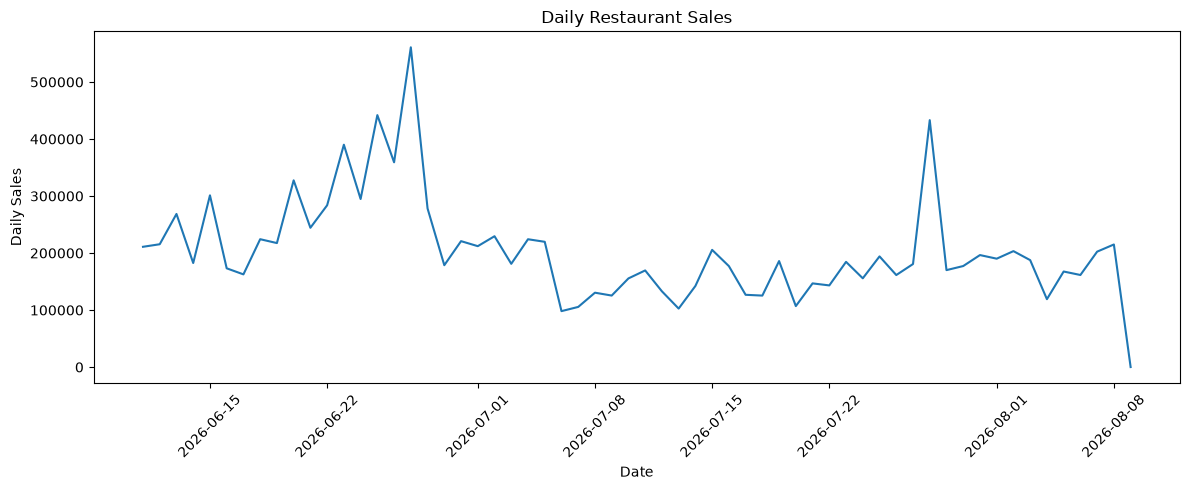

In [251]:
# Visulaize and Plot daily sales

plt.figure(figsize=(12, 5))

plt.plot(
    daily_df["Date"],
    daily_df["DailySales"]
)

plt.title("Daily Restaurant Sales")
plt.xlabel("Date")
plt.ylabel("Daily Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [252]:
# We group sales by each day of the week creat day of week columns and calculate the average to see which days usually have higher or lower sales.

daily_df["Day_of_Week"] = (
    daily_df["Date"].dt.day_name()
)

day_sales = (
    daily_df.groupby("Day_of_Week")["DailySales"]
    .mean()
)

day_sales

Day_of_Week
Friday       201112.773056
Monday       179948.662125
Saturday     252795.942722
Sunday       178702.048389
Thursday     214708.584167
Tuesday      216342.881750
Wednesday    185791.665500
Name: DailySales, dtype: float64

In [253]:
# Correct day order

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

day_sales

Day_of_Week
Monday       179948.662125
Tuesday      216342.881750
Wednesday    185791.665500
Thursday     214708.584167
Friday       201112.773056
Saturday     252795.942722
Sunday       178702.048389
Name: DailySales, dtype: float64

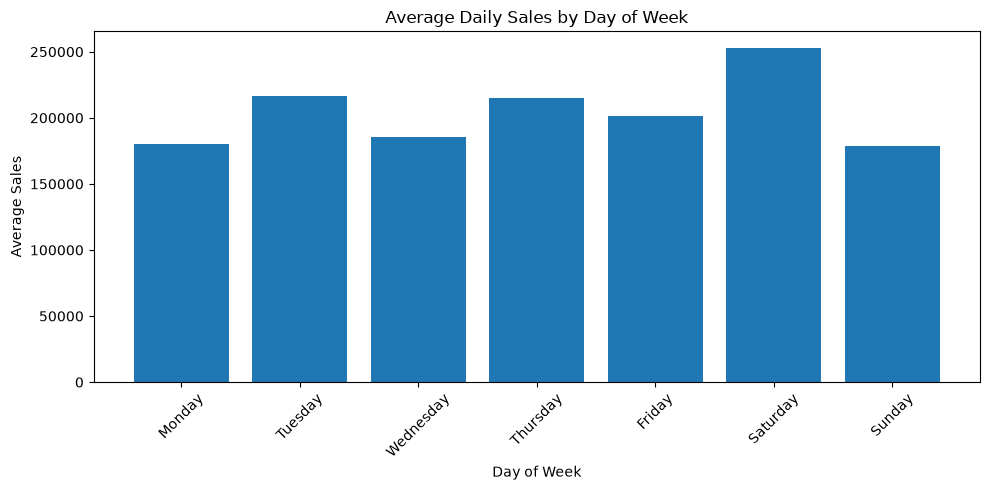

In [254]:
#Visualize the Average sales by day of week

plt.figure(figsize=(10, 5))

plt.bar(
    day_sales.index,
    day_sales.values
)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Time and Calendar Feature Engineering

We take the Date and create extra information from it so the model can understand when a sale happened

These features allow the machine-learning models to learn patterns related to:

- Time progression
- Day of the week
- Month
- Quarter
- Weekend days
- Beginning of a month

**We create time and calendar features so the model can learn how sales behave over time, different days, months, and weekends.**

In [255]:
# Create basic time features

daily_df["day_index"] = (
    daily_df["Date"] - daily_df["Date"].min()
).dt.days

daily_df["day_of_week"] = (
    daily_df["Date"].dt.dayofweek
)

daily_df["month"] = (
    daily_df["Date"].dt.month
)

daily_df["quarter"] = (
    daily_df["Date"].dt.quarter
)

daily_df["year"] = (
    daily_df["Date"].dt.year
)

daily_df["is_weekend"] = (
    daily_df["day_of_week"] >= 5
).astype(int)

daily_df["is_month_start"] = (
    daily_df["Date"].dt.is_month_start
).astype(int)

In [256]:
# Display the new features

daily_df[
    [
        "Date",
        "day_index",
        "day_of_week",
        "month",
        "quarter",
        "year",
        "is_weekend",
        "is_month_start"
    ]
].head(10)

,Date,day_index,day_of_week,month,quarter,year,is_weekend,is_month_start
0,2026-06-11,0,3,6,2,2026,0,0
1,2026-06-12,1,4,6,2,2026,0,0
2,2026-06-13,2,5,6,2,2026,1,0
3,2026-06-14,3,6,6,2,2026,1,0
4,2026-06-15,4,0,6,2,2026,0,0
5,2026-06-16,5,1,6,2,2026,0,0
6,2026-06-17,6,2,6,2,2026,0,0
7,2026-06-18,7,3,6,2,2026,0,0
8,2026-06-19,8,4,6,2,2026,0,0
9,2026-06-20,9,5,6,2,2026,1,0


### Cyclic Feature Engineering

Day of week and month are cyclical variables.

We use sine and cosine transformations to represent their cyclical nature.

Sine and cosine help the model understand that time cycles repeat and their ends connect back to their beginnings.

We create:

- `dow_sin`
- `dow_cos`
- `month_sin`
- `month_cos`

**We use cyclical encoding so the model can better learn repeating weekly patterns and monthly patterns.**

In [257]:
# Cyclic encoding for day of week

daily_df["dow_sin"] = np.sin(
    2 * np.pi * daily_df["day_of_week"] / 7
)

daily_df["dow_cos"] = np.cos(
    2 * np.pi * daily_df["day_of_week"] / 7
)

In [258]:
# Cyclic encoding for month

daily_df["month_sin"] = np.sin(
    2 * np.pi * daily_df["month"] / 12
)

daily_df["month_cos"] = np.cos(
    2 * np.pi * daily_df["month"] / 12
)

In [259]:
# Display cyclic features

daily_df[
    [
        "Date",
        "day_of_week",
        "dow_sin",
        "dow_cos",
        "month",
        "month_sin",
        "month_cos"
    ]
].head(10)

,Date,day_of_week,dow_sin,dow_cos,month,month_sin,month_cos
0,2026-06-11,3,0.433884,-0.900969,6,1.224647e-16,-1.0
1,2026-06-12,4,-0.433884,-0.900969,6,1.224647e-16,-1.0
2,2026-06-13,5,-0.974928,-0.222521,6,1.224647e-16,-1.0
3,2026-06-14,6,-0.781831,0.623490,6,1.224647e-16,-1.0
4,2026-06-15,0,0.000000,1.000000,6,1.224647e-16,-1.0
5,2026-06-16,1,0.781831,0.623490,6,1.224647e-16,-1.0
6,2026-06-17,2,0.974928,-0.222521,6,1.224647e-16,-1.0
7,2026-06-18,3,0.433884,-0.900969,6,1.224647e-16,-1.0
8,2026-06-19,4,-0.433884,-0.900969,6,1.224647e-16,-1.0
9,2026-06-20,5,-0.974928,-0.222521,6,1.224647e-16,-1.0


### Create Lag Features
#### Lag Feature Engineering

Lag features use previous sales observations as input features.

Lag features give the model information about previous sales so it can learn from the past and predict the future.

We create the following lag features:

- Lag 1
- Lag 2
- Lag 3
- Lag 5
- Lag 7
- Lag 14
- Lag 21
- Lag 28

In [260]:
# Create lag features

lag_days = [
    1,
    2,
    3,
    5,
    7,
    14,
    21,
    28
]

for lag in lag_days:
    daily_df[f"lag_{lag}"] = (
        daily_df["DailySales"].shift(lag)
    )

In [261]:
# Display lag features

daily_df[
    [
        "Date",
        "DailySales",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_5",
        "lag_7",
        "lag_14",
        "lag_21",
        "lag_28"
    ]
].head(35)

,Date,DailySales,lag_1,lag_2,lag_3,lag_5,lag_7,lag_14,lag_21,lag_28
0,2026-06-11,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-12,215435.2615,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-13,268560.5235,215435.2615,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-06-14,182505.2185,268560.5235,215435.2615,210960.4390,NaN,NaN,NaN,NaN,NaN
4,2026-06-15,301205.5505,182505.2185,268560.5235,215435.2615,NaN,NaN,NaN,NaN,NaN
5,2026-06-16,173220.2105,301205.5505,182505.2185,268560.5235,210960.4390,NaN,NaN,NaN,NaN
6,2026-06-17,162585.1255,173220.2105,301205.5505,182505.2185,215435.2615,NaN,NaN,NaN,NaN
7,2026-06-18,224273.9660,162585.1255,173220.2105,301205.5505,268560.5235,210960.4390,NaN,NaN,NaN
8,2026-06-19,217485.2055,224273.9660,162585.1255,173220.2105,182505.2185,215435.2615,NaN,NaN,NaN
9,2026-06-20,327490.5025,217485.2055,224273.9660,162585.1255,301205.5505,268560.5235,NaN,NaN,NaN


### Create Rolling Features
#### Rolling Feature Engineering

Rolling features summarize recent sales to help the model understand the average, variation, lowest, and highest sales.

They help the model understand:

- Recent average sales
- Sales variability
- Recent minimum sales
- Recent maximum sales

We create rolling features using windows of 3, 7, 14, and 30 days.

In [262]:
# Rolling mean features

daily_df["rolling_mean_3"] = (
    daily_df["DailySales"]
    .rolling(3)
    .mean()
)

daily_df["rolling_mean_7"] = (
    daily_df["DailySales"]
    .rolling(7)
    .mean()
)

daily_df["rolling_mean_14"] = (
    daily_df["DailySales"]
    .rolling(14)
    .mean()
)

daily_df["rolling_mean_30"] = (
    daily_df["DailySales"]
    .rolling(30)
    .mean()
)

In [263]:
# Rolling standard deviation features

daily_df["rolling_std_3"] = (
    daily_df["DailySales"]
    .rolling(3)
    .std()
)

daily_df["rolling_std_7"] = (
    daily_df["DailySales"]
    .rolling(7)
    .std()
)

daily_df["rolling_std_14"] = (
    daily_df["DailySales"]
    .rolling(14)
    .std()
)

daily_df["rolling_std_30"] = (
    daily_df["DailySales"]
    .rolling(30)
    .std()
)

In [264]:
# Rolling minimum and maximum

daily_df["rolling_min_3"] = (
    daily_df["DailySales"]
    .rolling(3)
    .min()
)

daily_df["rolling_min_7"] = (
    daily_df["DailySales"]
    .rolling(7)
    .min()
)

daily_df["rolling_max_3"] = (
    daily_df["DailySales"]
    .rolling(3)
    .max()
)

daily_df["rolling_max_7"] = (
    daily_df["DailySales"]
    .rolling(7)
    .max()
)

In [265]:
# Display rolling features

daily_df[
    [
        "Date",
        "DailySales",
        "rolling_mean_3",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_30",
        "rolling_std_3",
        "rolling_std_7"
    ]
].head(35)

,Date,DailySales,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_3,rolling_std_7
0,2026-06-11,210960.4390,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-12,215435.2615,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-13,268560.5235,231652.074667,NaN,NaN,NaN,32041.866449,NaN
3,2026-06-14,182505.2185,222167.001167,NaN,NaN,NaN,43420.802835,NaN
4,2026-06-15,301205.5505,250757.097500,NaN,NaN,NaN,61320.173575,NaN
5,2026-06-16,173220.2105,218976.993167,NaN,NaN,NaN,71363.187809,NaN
6,2026-06-17,162585.1255,212336.962167,216353.189857,NaN,NaN,77145.938017,51401.356929
7,2026-06-18,224273.9660,186693.100667,218255.122286,NaN,NaN,32977.527767,51414.868908
8,2026-06-19,217485.2055,201448.099000,218547.971429,NaN,NaN,33827.057945,51401.967053
9,2026-06-20,327490.5025,256416.558000,226966.539857,NaN,NaN,61645.364849,64192.531955


### Create Change and Ratio Features
#### Sales Change and Ratio Features

We create additional features that describe changes in sales and relationships between current sales and historical averages.

These features help the model understand sales changes and compare current sales with normal or recent sales.

These include:

- Daily change
- Weekly change
- Day-of-week average
- Sales relative to day-of-week average
- Sales relative to moving averages
- Ratio between short-term and medium-term volatility

In [266]:
# Daily and weekly sales changes

daily_df["daily_change"] = (
    daily_df["DailySales"].pct_change()
)

daily_df["weekly_change"] = (
    daily_df["DailySales"].pct_change(7)
)

In [267]:
# Average sales for each day of the week

dow_average = (
    daily_df.groupby("day_of_week")["DailySales"]
    .transform("mean")
)

daily_df["dow_avg"] = dow_average

In [268]:
# Sales compared with the average for that day of the week

daily_df["sales_to_dow_avg"] = (
    daily_df["DailySales"] /
    daily_df["dow_avg"]
)

In [269]:
# Sales compared with moving averages

daily_df["sales_to_ma_7"] = (
    daily_df["DailySales"] /
    daily_df["rolling_mean_7"]
)

daily_df["sales_to_ma_14"] = (
    daily_df["DailySales"] /
    daily_df["rolling_mean_14"]
)

In [270]:
# Short-term volatility compared with 7-day volatility

daily_df["std_ratio_3_7"] = (
    daily_df["rolling_std_3"] /
    daily_df["rolling_std_7"]
)

In [271]:
# Display change and ratio features

daily_df[
    [
        "Date",
        "DailySales",
        "daily_change",
        "weekly_change",
        "dow_avg",
        "sales_to_dow_avg",
        "sales_to_ma_7",
        "sales_to_ma_14",
        "std_ratio_3_7"
    ]
].head(35)

,Date,DailySales,daily_change,weekly_change,dow_avg,sales_to_dow_avg,sales_to_ma_7,sales_to_ma_14,std_ratio_3_7
0,2026-06-11,210960.4390,NaN,NaN,214708.584167,0.982543,NaN,NaN,NaN
1,2026-06-12,215435.2615,0.021212,NaN,201112.773056,1.071216,NaN,NaN,NaN
2,2026-06-13,268560.5235,0.246595,NaN,252795.942722,1.062361,NaN,NaN,NaN
3,2026-06-14,182505.2185,-0.320432,NaN,178702.048389,1.021282,NaN,NaN,NaN
4,2026-06-15,301205.5505,0.650394,NaN,179948.662125,1.673842,NaN,NaN,NaN
5,2026-06-16,173220.2105,-0.424910,NaN,216342.881750,0.800674,NaN,NaN,NaN
6,2026-06-17,162585.1255,-0.061396,NaN,185791.665500,0.875094,0.751480,NaN,1.500854
7,2026-06-18,224273.9660,0.379425,0.063109,214708.584167,1.044551,1.027577,NaN,0.641401
8,2026-06-19,217485.2055,-0.030270,0.009515,201112.773056,1.081409,0.995137,NaN,0.658089
9,2026-06-20,327490.5025,0.505806,0.219429,252795.942722,1.295474,1.442902,NaN,0.960320


### Review and Correct the Engineered Feature
#### Prevent Data Leakage

For forecasting, features must be created using information that would have been available at prediction time.

We review the engineered features to check that they only use past information. This prevents the model from seeing the future and causing data leakage.

This prevents data leakage and makes the forecasting pipeline realistic.

In [272]:
# Recreate rolling features using previous sales only

daily_df["rolling_mean_3"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(3)
    .mean()
)

daily_df["rolling_mean_7"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_df["rolling_mean_14"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(14)
    .mean()
)

daily_df["rolling_mean_30"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(30)
    .mean()
)

In [273]:
# Rolling standard deviation using previous observations

daily_df["rolling_std_3"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(3)
    .std()
)

daily_df["rolling_std_7"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(7)
    .std()
)

daily_df["rolling_std_14"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(14)
    .std()
)

daily_df["rolling_std_30"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(30)
    .std()
)

In [274]:
# Rolling minimum and maximum using previous observations

daily_df["rolling_min_3"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(3)
    .min()
)

daily_df["rolling_min_7"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(7)
    .min()
)

daily_df["rolling_max_3"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(3)
    .max()
)

daily_df["rolling_max_7"] = (
    daily_df["DailySales"]
    .shift(1)
    .rolling(7)
    .max()
)

In [275]:
# Changes based only on previous sales

daily_df["daily_change"] = (
    daily_df["DailySales"].shift(1).pct_change()
)

daily_df["weekly_change"] = (
    daily_df["DailySales"].shift(1).pct_change(7)
)

In [276]:
# Ratios using previous sales information

daily_df["sales_to_ma_7"] = (
    daily_df["DailySales"].shift(1) /
    daily_df["rolling_mean_7"]
)

daily_df["sales_to_ma_14"] = (
    daily_df["DailySales"].shift(1) /
    daily_df["rolling_mean_14"]
)

daily_df["std_ratio_3_7"] = (
    daily_df["rolling_std_3"] /
    daily_df["rolling_std_7"]
)

In [277]:
# Day-of-week average from previous observations

daily_df["dow_avg"] = (
    daily_df.groupby("day_of_week")["DailySales"]
    .transform(
        lambda x: x.shift(1).expanding().mean()
    )
)

In [278]:
# Sales relative to previous day-of-week average

daily_df["sales_to_dow_avg"] = (
    daily_df["DailySales"].shift(1) /
    daily_df["dow_avg"]
)

In [279]:
# Show all columns

print("Number of columns:", len(daily_df.columns))
print(daily_df.columns.tolist())

Number of columns: 41
['Date', 'DailySales', 'Day_of_Week', 'day_index', 'day_of_week', 'month', 'quarter', 'year', 'is_weekend', 'is_month_start', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_3', 'rolling_std_7', 'rolling_std_14', 'rolling_std_30', 'rolling_min_3', 'rolling_min_7', 'rolling_max_3', 'rolling_max_7', 'daily_change', 'weekly_change', 'dow_avg', 'sales_to_dow_avg', 'sales_to_ma_7', 'sales_to_ma_14', 'std_ratio_3_7']


### Feature Selection Strategy — Manual + Automatic

Feature selection is **not based on correlation alone**.

For this time-series forecasting problem we use three complementary ideas:

1. **Correlation analysis** — identifies redundant features and is used as a diagnostic. A useful seasonal feature is **not dropped solely because it is correlated** with another feature.
2. **Manual/domain selection** — protects important forecasting structure, especially weekly seasonality and recent sales history.
3. **Automatic model-based importance** — Random Forest feature importance is calculated using **training data only** and combined across the forecasting horizons.

The final feature set is **exactly 12 features**. We first preserve the manually important forecasting features, then fill the remaining positions with the highest-ranked automatic features. This keeps useful time-series information such as `dow_sin` and `dow_cos` from being removed by correlation alone.

The chronological test period is never used for feature selection.


In [280]:
# Candidate feature pool

candidate_features = [
    "day_index",
    "day_of_week",
    "month",
    "quarter",
    "is_weekend",
    "is_month_start",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_5",
    "lag_7",
    "lag_14",
    "lag_21",
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "weekly_change",
    "sales_to_ma_7"
]

print("Number of candidate features:", len(candidate_features))
print(candidate_features)


Number of candidate features: 20
['day_index', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_month_start', 'dow_sin', 'dow_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14', 'weekly_change', 'sales_to_ma_7']


In [281]:
# Display the candidate features by category

feature_categories = {
    "Calendar / trend": [
        "day_index", "day_of_week", "month", "quarter",
        "is_weekend", "is_month_start"
    ],
    "Weekly seasonality": [
        "dow_sin", "dow_cos"
    ],
    "Lag history/past": [
        "lag_1", "lag_2", "lag_3", "lag_5", "lag_7", "lag_14", "lag_21"
    ],
    "Recent level": [
        "rolling_mean_3", "rolling_mean_7", "rolling_mean_14"
    ],
    "Change / relative level": [
        "weekly_change", "sales_to_ma_7"
    ]
}

for category, features in feature_categories.items():
    print(f"\n{category}:")
    for feature in features:
        print(" -", feature)



Calendar / trend:
 - day_index
 - day_of_week
 - month
 - quarter
 - is_weekend
 - is_month_start

Weekly seasonality:
 - dow_sin
 - dow_cos

Lag history/past:
 - lag_1
 - lag_2
 - lag_3
 - lag_5
 - lag_7
 - lag_14
 - lag_21

Recent level:
 - rolling_mean_3
 - rolling_mean_7
 - rolling_mean_14

Change / relative level:
 - weekly_change
 - sales_to_ma_7


#### Correlation Analysis — Diagnostic Only

A high correlation means two features contain overlapping information. In forecasting, however, correlation alone does **not** prove that one feature is useless.

For example, `dow_sin`, `dow_cos`, `day_of_week`, and `is_weekend` describe different representations of weekly seasonality. We therefore inspect correlation and let model-based importance plus domain knowledge make the final decision.


In [282]:
# Correlation matrix of the candidate features

correlation_matrix = daily_df[candidate_features].corr()
correlation_matrix


,day_index,day_of_week,month,quarter,is_weekend,is_month_start,dow_sin,dow_cos,lag_1,lag_2,lag_3,lag_5,lag_7,lag_14,lag_21,rolling_mean_3,rolling_mean_7,rolling_mean_14,weekly_change,sales_to_ma_7
day_index,1.000000,0.029513,0.903383,8.166100e-01,3.780170e-02,0.064336,-0.015064,0.018845,-0.358042,-0.369711,-0.377554,-0.368577,-0.351156,-0.488544,-0.449549,-0.459549,-0.528728,-0.702169,-0.022739,0.004428
day_of_week,0.029513,1.000000,0.063721,1.777421e-02,7.898745e-01,0.037342,-0.744322,-0.323754,0.163178,-0.105722,-0.065669,-0.005602,0.102327,0.165152,0.142462,-0.003922,-0.016033,0.010209,-0.016359,0.199051
month,0.903383,0.063721,1.000000,8.611081e-01,7.050344e-02,0.189218,-0.038873,-0.002754,-0.460131,-0.486475,-0.482096,-0.253714,-0.144752,-0.241801,-0.389548,-0.588062,-0.471505,-0.396707,-0.284988,-0.189757
quarter,0.816610,0.017774,0.861108,1.000000e+00,-9.422112e-17,0.131306,0.019504,-0.034459,-0.562242,-0.586086,-0.567047,-0.357565,-0.215081,-0.062956,NaN,-0.710019,-0.624065,-0.500843,-0.350682,-0.202273
is_weekend,0.037802,0.789875,0.070503,-9.422112e-17,1.000000e+00,0.081044,-0.787601,0.207130,0.141818,-0.001129,-0.051552,-0.082123,0.125439,0.169574,0.161000,0.036540,-0.011235,0.001894,-0.035114,0.165848
is_month_start,0.064336,0.037342,0.189218,1.313064e-01,8.104409e-02,1.000000,0.007704,-0.052280,0.001018,-0.064342,0.034051,0.129237,0.070702,-0.154299,-0.085762,-0.011720,0.200282,0.122775,-0.066742,-0.146438
dow_sin,-0.015064,-0.744322,-0.038873,1.950390e-02,-7.876013e-01,0.007704,1.000000,-0.010399,-0.127521,-0.045522,0.070814,0.110207,-0.081232,-0.144930,-0.138908,-0.041611,0.006423,-0.014800,0.072434,-0.167611
dow_cos,0.018845,-0.323754,-0.002754,-3.445886e-02,2.071297e-01,-0.052280,-0.010399,1.000000,0.044017,0.127787,0.117589,-0.077903,-0.069963,-0.134657,-0.115755,0.118609,0.006034,-0.019197,-0.039753,0.032308
lag_1,-0.358042,0.163178,-0.460131,-5.622421e-01,1.418176e-01,0.001018,-0.127521,0.044017,1.000000,0.517337,0.486272,0.332206,0.154184,-0.062398,-0.260880,0.815109,0.651687,0.413325,0.679267,0.684131
lag_2,-0.369711,-0.105722,-0.486475,-5.860859e-01,-1.128557e-03,-0.064342,-0.045522,0.127787,0.517337,1.000000,0.517469,0.400625,0.339062,0.031521,-0.194386,0.827802,0.728524,0.491374,0.291756,0.032675


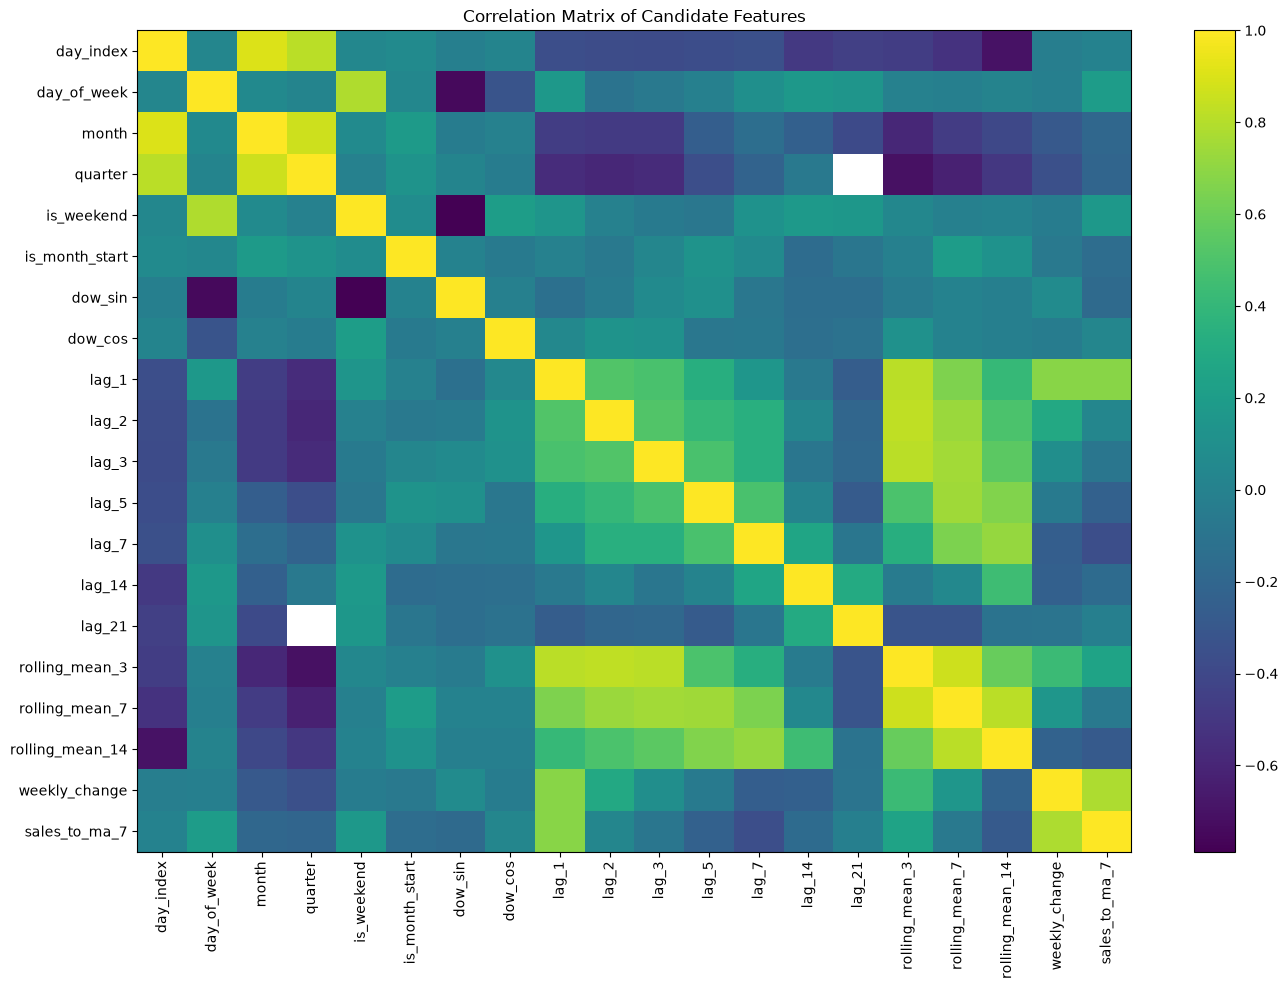

In [283]:
# Plot candidate-feature correlation matrix

plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(candidate_features)),
    candidate_features,
    rotation=90
)
plt.yticks(
    range(len(candidate_features)),
    candidate_features
)

plt.title("Correlation Matrix of Candidate Features")
plt.tight_layout()
plt.show()


In [284]:
# Find strongly correlated candidate-feature pairs

correlation_pairs = []

for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):
        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) >= 0.80:
            correlation_pairs.append({
                "Feature_1": candidate_features[i],
                "Feature_2": candidate_features[j],
                "Correlation": correlation
            })

correlation_pairs_df = pd.DataFrame(correlation_pairs)

if len(correlation_pairs_df) > 0:
    correlation_pairs_df["Absolute_Correlation"] = (
        correlation_pairs_df["Correlation"].abs()
    )
    correlation_pairs_df = correlation_pairs_df.sort_values(
        "Absolute_Correlation",
        ascending=False
    )

correlation_pairs_df


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,day_index,month,0.903383,0.903383
6,rolling_mean_3,rolling_mean_7,0.862182,0.862182
2,month,quarter,0.861108,0.861108
4,lag_2,rolling_mean_3,0.827802,0.827802
1,day_index,quarter,0.816610,0.816610
7,rolling_mean_7,rolling_mean_14,0.816335,0.816335
5,lag_3,rolling_mean_3,0.815164,0.815164
3,lag_1,rolling_mean_3,0.815109,0.815109


In [285]:
# Correlation review rule

print(
    "Correlation threshold used for review: |r| >= 0.80"
)
print(
    "Important: correlated features are reviewed, not automatically dropped."
)
print(
    "The final decision is made after training-only model importance is available."
)


Correlation threshold used for review: |r| >= 0.80
Important: correlated features are reviewed, not automatically dropped.
The final decision is made after training-only model importance is available.


In [286]:
# Temporary feature list before target-aware selection

# Keep all candidates available until the chronological train/test split.
# The actual final selection is performed later using training data only.

final_features = candidate_features.copy()

print(
    "Features available before automatic/manual selection:",
    len(final_features)
)


Features available before automatic/manual selection: 20


In [287]:
# Verify that the working feature list contains only candidate features

assert set(final_features).issubset(set(candidate_features))

print("All working features are valid candidate features.")


All working features are valid candidate features.


In [288]:
# Display the complete candidate feature table

daily_df[
    ["Date", "DailySales"] + candidate_features
].head()


,Date,DailySales,day_index,day_of_week,month,quarter,is_weekend,is_month_start,dow_sin,dow_cos,...,lag_3,lag_5,lag_7,lag_14,lag_21,rolling_mean_3,rolling_mean_7,rolling_mean_14,weekly_change,sales_to_ma_7
0,2026-06-11,210960.4390,0,3,6,2,0,0,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-12,215435.2615,1,4,6,2,0,0,-0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-06-13,268560.5235,2,5,6,2,1,0,-0.974928,-0.222521,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-06-14,182505.2185,3,6,6,2,1,0,-0.781831,0.623490,...,210960.4390,NaN,NaN,NaN,NaN,231652.074667,NaN,NaN,NaN,NaN
4,2026-06-15,301205.5505,4,0,6,2,0,0,0.000000,1.000000,...,215435.2615,NaN,NaN,NaN,NaN,222167.001167,NaN,NaN,NaN,NaN


## Feature Selection Checkpoint

We begin with **20 candidate features**. The final feature set must contain ** 12 features**, as required.

The selection decision combines:
- **Correlation analysis** to identify redundancy, not to blindly delete useful variables.
- **Manual/domain knowledge** to protect essential time-series structure.
- **Training-only Random Forest importance** to rank features according to predictive usefulness.

The final 12 are selected only after the chronological train/test split, so the test period does not influence feature selection.


In [289]:
# Candidate correlation matrix — final diagnostic view

candidate_correlation = daily_df[candidate_features].corr()
candidate_correlation


,day_index,day_of_week,month,quarter,is_weekend,is_month_start,dow_sin,dow_cos,lag_1,lag_2,lag_3,lag_5,lag_7,lag_14,lag_21,rolling_mean_3,rolling_mean_7,rolling_mean_14,weekly_change,sales_to_ma_7
day_index,1.000000,0.029513,0.903383,8.166100e-01,3.780170e-02,0.064336,-0.015064,0.018845,-0.358042,-0.369711,-0.377554,-0.368577,-0.351156,-0.488544,-0.449549,-0.459549,-0.528728,-0.702169,-0.022739,0.004428
day_of_week,0.029513,1.000000,0.063721,1.777421e-02,7.898745e-01,0.037342,-0.744322,-0.323754,0.163178,-0.105722,-0.065669,-0.005602,0.102327,0.165152,0.142462,-0.003922,-0.016033,0.010209,-0.016359,0.199051
month,0.903383,0.063721,1.000000,8.611081e-01,7.050344e-02,0.189218,-0.038873,-0.002754,-0.460131,-0.486475,-0.482096,-0.253714,-0.144752,-0.241801,-0.389548,-0.588062,-0.471505,-0.396707,-0.284988,-0.189757
quarter,0.816610,0.017774,0.861108,1.000000e+00,-9.422112e-17,0.131306,0.019504,-0.034459,-0.562242,-0.586086,-0.567047,-0.357565,-0.215081,-0.062956,NaN,-0.710019,-0.624065,-0.500843,-0.350682,-0.202273
is_weekend,0.037802,0.789875,0.070503,-9.422112e-17,1.000000e+00,0.081044,-0.787601,0.207130,0.141818,-0.001129,-0.051552,-0.082123,0.125439,0.169574,0.161000,0.036540,-0.011235,0.001894,-0.035114,0.165848
is_month_start,0.064336,0.037342,0.189218,1.313064e-01,8.104409e-02,1.000000,0.007704,-0.052280,0.001018,-0.064342,0.034051,0.129237,0.070702,-0.154299,-0.085762,-0.011720,0.200282,0.122775,-0.066742,-0.146438
dow_sin,-0.015064,-0.744322,-0.038873,1.950390e-02,-7.876013e-01,0.007704,1.000000,-0.010399,-0.127521,-0.045522,0.070814,0.110207,-0.081232,-0.144930,-0.138908,-0.041611,0.006423,-0.014800,0.072434,-0.167611
dow_cos,0.018845,-0.323754,-0.002754,-3.445886e-02,2.071297e-01,-0.052280,-0.010399,1.000000,0.044017,0.127787,0.117589,-0.077903,-0.069963,-0.134657,-0.115755,0.118609,0.006034,-0.019197,-0.039753,0.032308
lag_1,-0.358042,0.163178,-0.460131,-5.622421e-01,1.418176e-01,0.001018,-0.127521,0.044017,1.000000,0.517337,0.486272,0.332206,0.154184,-0.062398,-0.260880,0.815109,0.651687,0.413325,0.679267,0.684131
lag_2,-0.369711,-0.105722,-0.486475,-5.860859e-01,-1.128557e-03,-0.064342,-0.045522,0.127787,0.517337,1.000000,0.517469,0.400625,0.339062,0.031521,-0.194386,0.827802,0.728524,0.491374,0.291756,0.032675


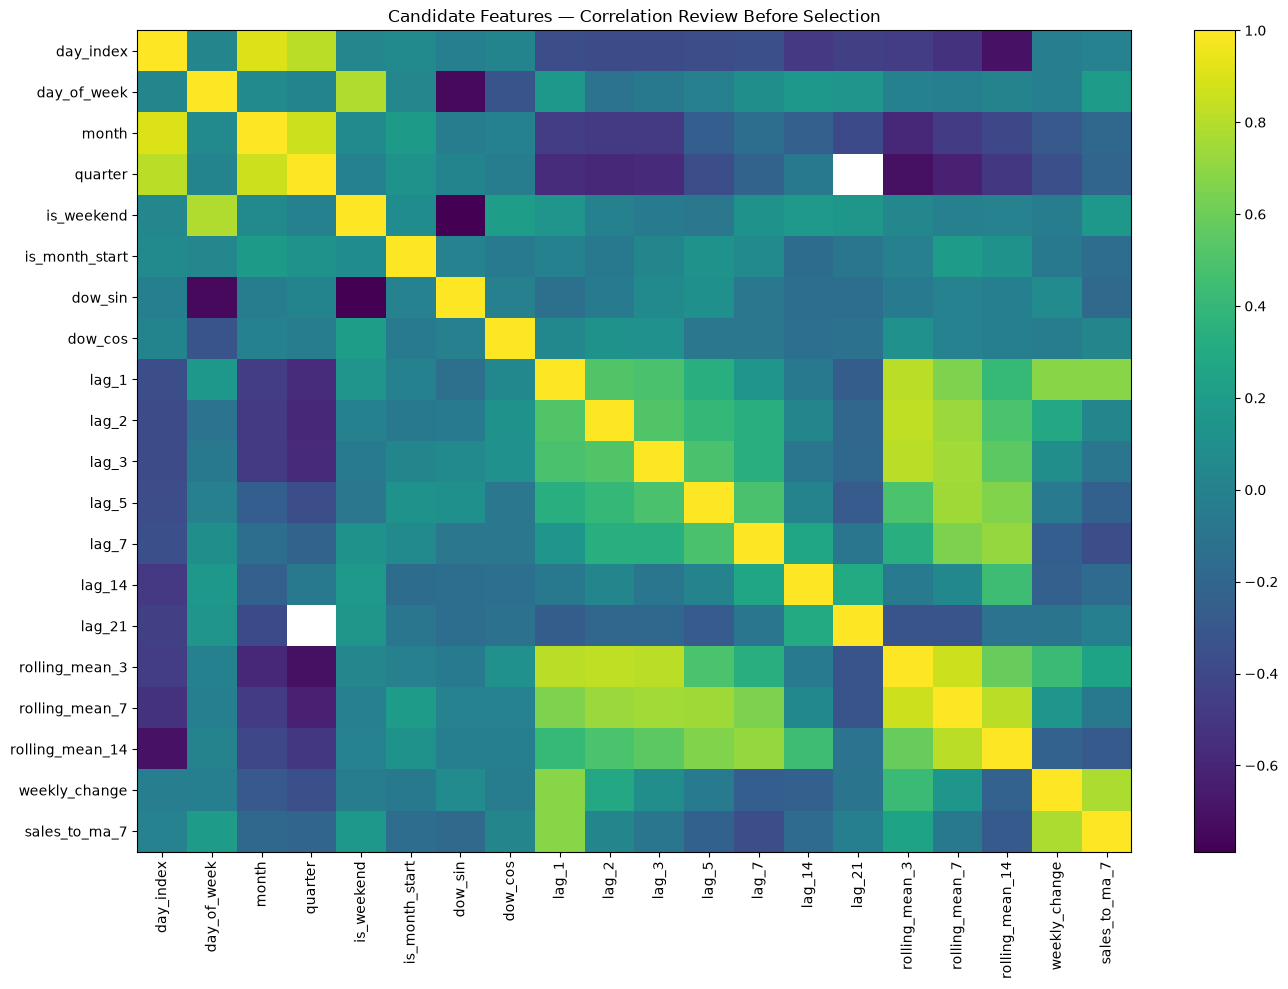

In [290]:
# Display the candidate-feature correlation heatmap again for review

plt.figure(figsize=(14, 10))
plt.imshow(candidate_correlation, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(candidate_features)),
    candidate_features,
    rotation=90
)
plt.yticks(
    range(len(candidate_features)),
    candidate_features
)

plt.title("Candidate Features — Correlation Review Before Selection")
plt.tight_layout()
plt.show()


In [291]:
print("Candidate feature count before target-aware selection:", len(candidate_features))


Candidate feature count before target-aware selection: 20


#### Create Forecasting Targets

We create three targets because we want the model to predict sales for the next 1 day, 7 days, and 30 days.

- `target_1d` represents sales on the following day.
- `target_7d` represents total sales over the following 7 days.
- `target_30d` represents total sales over the following 30 days.

The targets are created by shifting future sales forward.

The 30-day target will only be used if enough observations are available.

In [292]:
# Next-day sales target

daily_df["target_1d"] = (
    daily_df["DailySales"].shift(-1)
)

In [293]:
# Next 7-day total sales target

daily_df["target_7d"] = (
    daily_df["DailySales"]
    .shift(-1)
    .rolling(7)
    .sum()
    .shift(-6)
)

In [294]:
# Next 30-day total sales target

daily_df["target_30d"] = (
    daily_df["DailySales"]
    .shift(-1)
    .rolling(30)
    .sum()
    .shift(-29)
)

In [295]:
# Display targets

daily_df[
    [
        "Date",
        "DailySales",
        "target_1d",
        "target_7d",
        "target_30d"
    ]
].tail(35)

,Date,DailySales,target_1d,target_7d,target_30d
25,2026-07-06,98125.2565,105505.1745,9.218776e+05,5.002780e+06
26,2026-07-07,105505.1745,130468.7880,9.586204e+05,5.058776e+06
27,2026-07-08,130468.7880,125428.0045,1.033699e+06,5.130757e+06
28,2026-07-09,125428.0045,155506.2430,1.085379e+06,5.220346e+06
29,2026-07-10,155506.2430,169486.7930,1.056638e+06,5.064910e+06
30,2026-07-11,169486.7930,132883.6385,1.012538e+06,NaN
31,2026-07-12,132883.6385,102598.9750,1.065593e+06,NaN
32,2026-07-13,102598.9750,142247.9275,1.069952e+06,NaN
33,2026-07-14,142247.9275,205547.3085,1.074480e+06,NaN
34,2026-07-15,205547.3085,177107.8775,1.012170e+06,NaN


In [296]:
# Count usable target observations

print(
    "Usable 1-day observations:",
    daily_df["target_1d"].notna().sum()
)

print(
    "Usable 7-day observations:",
    daily_df["target_7d"].notna().sum()
)

print(
    "Usable 30-day observations:",
    daily_df["target_30d"].notna().sum()
)

Usable 1-day observations: 59
Usable 7-day observations: 53
Usable 30-day observations: 30


#### Create the Final Modeling Dataset

We use the selected feature set produced by the training-only manual + automatic feature-selection stage for model training.

The target variables are:

- `target_1d`
- `target_7d`
- `target_30d`

We prepare the modeling dataset using the full candidate pool first, then train models using only the selected features. 

We remove rows with missing values so the model trains only on complete data



In [297]:
# Columns needed for modeling
#This code creates a smaller dataset containing the date, sales, 12 selected features, and the 3 forecasting targets that we need for modeling.

model_columns = (
    ["Date", "DailySales"]
    + final_features
    + [
        "target_1d",
        "target_7d",
        "target_30d"
    ]
)

model_df = daily_df[
    model_columns
].copy()

print("Model dataset shape:", model_df.shape)

Model dataset shape: (60, 25)


In [298]:
#we create 1-Day modeling dataset
#We remove rows with missing features or missing 1-day targets, then count the usable observations and check their date range
data_1d = model_df.dropna(
    subset=final_features + ["target_1d"]
).copy()

print("1-Day usable observations:", len(data_1d))
print(
    "1-Day date range:",
    data_1d["Date"].min(),
    "to",
    data_1d["Date"].max()
)

1-Day usable observations: 38
1-Day date range: 2026-07-02 00:00:00 to 2026-08-08 00:00:00


In [299]:
# create 7-Day modeling dataset
#We remove rows with missing features or missing 7-day targets, then count the usable observations and check their date range
data_7d = model_df.dropna(
    subset=final_features + ["target_7d"]
).copy()

print("7-Day usable observations:", len(data_7d))
print(
    "7-Day date range:",
    data_7d["Date"].min(),
    "to",
    data_7d["Date"].max()
)

7-Day usable observations: 32
7-Day date range: 2026-07-02 00:00:00 to 2026-08-02 00:00:00


In [300]:
# create 30-Day modeling dataset
#We remove rows with missing features or missing 30-day targets, then count the usable observations and check their date range
data_30d = model_df.dropna(
    subset=final_features + ["target_30d"]
).copy()

print("30-Day usable observations:", len(data_30d))

if len(data_30d) > 0:
    print(
        "30-Day date range:",
        data_30d["Date"].min(),
        "to",
        data_30d["Date"].max()
    )
else:
    print("No usable 30-day observations.")

30-Day usable observations: 9
30-Day date range: 2026-07-02 00:00:00 to 2026-07-10 00:00:00


#### Final Modeling Data Quality Check

Before model training, we verify that:

- The selected feature set is being used and its final count is reported.
- There are no missing values in the features.
- There are no missing values in the target.
- The observations are in chronological order.

This ensures that the modeling datasets are ready for the train-test split.

In [301]:
# Confirm the final features

print("Number of final features:", len(final_features))
print()
print(final_features)

Number of final features: 20

['day_index', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_month_start', 'dow_sin', 'dow_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'rolling_mean_3', 'rolling_mean_7', 'rolling_mean_14', 'weekly_change', 'sales_to_ma_7']


In [302]:
# Check 1-day dataset

print("1-Day missing values:")
print(data_1d[final_features + ["target_1d"]].isnull().sum())

print()
print("Total missing values:",
      data_1d[final_features + ["target_1d"]].isnull().sum().sum())

1-Day missing values:
day_index          0
day_of_week        0
month              0
quarter            0
is_weekend         0
is_month_start     0
dow_sin            0
dow_cos            0
lag_1              0
lag_2              0
lag_3              0
lag_5              0
lag_7              0
lag_14             0
lag_21             0
rolling_mean_3     0
rolling_mean_7     0
rolling_mean_14    0
weekly_change      0
sales_to_ma_7      0
target_1d          0
dtype: int64

Total missing values: 0


In [303]:
# Check 7-day dataset

print("7-Day missing values:")
print(data_7d[final_features + ["target_7d"]].isnull().sum())

print()
print("Total missing values:",
      data_7d[final_features + ["target_7d"]].isnull().sum().sum())

7-Day missing values:
day_index          0
day_of_week        0
month              0
quarter            0
is_weekend         0
is_month_start     0
dow_sin            0
dow_cos            0
lag_1              0
lag_2              0
lag_3              0
lag_5              0
lag_7              0
lag_14             0
lag_21             0
rolling_mean_3     0
rolling_mean_7     0
rolling_mean_14    0
weekly_change      0
sales_to_ma_7      0
target_7d          0
dtype: int64

Total missing values: 0


In [304]:
# Check 30-day dataset

print("30-Day missing values:")
print(data_30d[final_features + ["target_30d"]].isnull().sum())

print()
print("Total missing values:",
      data_30d[final_features + ["target_30d"]].isnull().sum().sum())

30-Day missing values:
day_index          0
day_of_week        0
month              0
quarter            0
is_weekend         0
is_month_start     0
dow_sin            0
dow_cos            0
lag_1              0
lag_2              0
lag_3              0
lag_5              0
lag_7              0
lag_14             0
lag_21             0
rolling_mean_3     0
rolling_mean_7     0
rolling_mean_14    0
weekly_change      0
sales_to_ma_7      0
target_30d         0
dtype: int64

Total missing values: 0


In [305]:
# Check chronological order

print(
    "1-Day chronological:",
    data_1d["Date"].is_monotonic_increasing
)

print(
    "7-Day chronological:",
    data_7d["Date"].is_monotonic_increasing
)

print(
    "30-Day chronological:",
    data_30d["Date"].is_monotonic_increasing
)

1-Day chronological: True
7-Day chronological: True
30-Day chronological: True


In [306]:
# Final dataset summary

print("1-Day observations:", len(data_1d))
print("7-Day observations:", len(data_7d))
print("30-Day observations:", len(data_30d))

print("Number of features:", len(final_features))

1-Day observations: 38
7-Day observations: 32
30-Day observations: 9
Number of features: 20


#### Chronological Train/Test Split

Because this is a time-series forecasting problem, we do not randomly shuffle the observations.

Instead:

- past observations → Training data
- future observations → Testing data

This simulates a real forecasting situation where the model uses historical data to predict future sales.

We use 80% of the observations for training and 20% for testing.

In [307]:
# 1-Day chronological split

split_1d = int(len(data_1d) * 0.80)

train_1d = data_1d.iloc[:split_1d].copy()
test_1d = data_1d.iloc[split_1d:].copy()

print("1-Day training observations:", len(train_1d))
print("1-Day testing observations:", len(test_1d))

1-Day training observations: 30
1-Day testing observations: 8


In [308]:
# 7-Day chronological split

split_7d = int(len(data_7d) * 0.80)

train_7d = data_7d.iloc[:split_7d].copy()
test_7d = data_7d.iloc[split_7d:].copy()

print("7-Day training observations:", len(train_7d))
print("7-Day testing observations:", len(test_7d))

7-Day training observations: 25
7-Day testing observations: 7


In [309]:
# 30-Day chronological split

split_30d = int(len(data_30d) * 0.80)

train_30d = data_30d.iloc[:split_30d].copy()
test_30d = data_30d.iloc[split_30d:].copy()

print("30-Day training observations:", len(train_30d))
print("30-Day testing observations:", len(test_30d))

30-Day training observations: 7
30-Day testing observations: 2


In [310]:
# Check chronological split dates

print("1-Day:")
print("Training:", train_1d["Date"].min(), "to", train_1d["Date"].max())
print("Testing :", test_1d["Date"].min(), "to", test_1d["Date"].max())

print()

print("7-Day:")
print("Training:", train_7d["Date"].min(), "to", train_7d["Date"].max())
print("Testing :", test_7d["Date"].min(), "to", test_7d["Date"].max())

print()

print("30-Day:")
print("Training:", train_30d["Date"].min(), "to", train_30d["Date"].max())
print("Testing :", test_30d["Date"].min(), "to", test_30d["Date"].max())

1-Day:
Training: 2026-07-02 00:00:00 to 2026-07-31 00:00:00
Testing : 2026-08-01 00:00:00 to 2026-08-08 00:00:00

7-Day:
Training: 2026-07-02 00:00:00 to 2026-07-26 00:00:00
Testing : 2026-07-27 00:00:00 to 2026-08-02 00:00:00

30-Day:
Training: 2026-07-02 00:00:00 to 2026-07-08 00:00:00
Testing : 2026-07-09 00:00:00 to 2026-07-10 00:00:00


### Target-Aware Feature Selection — Training Data Only

Now that the targets and chronological train/test splits exist, we perform feature selection without leaking information from the future test period.

Separate Random Forest selector models are trained on the training portion for the 1-day, 7-day, and 30-day horizons. Their normalized feature importances are combined into one ranking.

We also protect important forecasting features based on domain knowledge:
- `day_index` → long-term trend
- `day_of_week` → weekly pattern
- `dow_sin`, `dow_cos` → cyclic weekly pattern
- `lag_1` → most recent sales
- `lag_7` → same weekday from the previous week
- `lag_14` → two-week weekly memory
- `rolling_mean_7` → recent weekly sales level

These protected features are **not automatically dropped because of correlation**. Their importance is still reported so we can audit the final decision.


In [311]:
# Prepare training-only candidate matrices

X_train_candidates_1d = train_1d[candidate_features]
y_train_candidates_1d = train_1d["target_1d"]

X_train_candidates_7d = train_7d[candidate_features]
y_train_candidates_7d = train_7d["target_7d"]

X_train_candidates_30d = train_30d[candidate_features]
y_train_candidates_30d = train_30d["target_30d"]

print("Training candidate shapes:")
print("1-Day :", X_train_candidates_1d.shape)
print("7-Day :", X_train_candidates_7d.shape)
print("30-Day:", X_train_candidates_30d.shape)


Training candidate shapes:
1-Day : (30, 20)
7-Day : (25, 20)
30-Day: (7, 20)


In [312]:
# Automatic feature-importance models — TRAINING DATA ONLY

rf_selector_1d = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_selector_7d = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_selector_30d = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_selector_1d.fit(
    X_train_candidates_1d,
    y_train_candidates_1d
)

rf_selector_7d.fit(
    X_train_candidates_7d,
    y_train_candidates_7d
)

rf_selector_30d.fit(
    X_train_candidates_30d,
    y_train_candidates_30d
)

print("Training-only feature importance models completed.")


Training-only feature importance models completed.


In [313]:
# Combine feature importance across forecasting horizons

importance_selection = pd.DataFrame({
    "Feature": candidate_features,
    "Importance_1d": rf_selector_1d.feature_importances_,
    "Importance_7d": rf_selector_7d.feature_importances_,
    "Importance_30d": rf_selector_30d.feature_importances_
})

# Normalize each horizon so a large-scale target does not dominate the ranking.
for horizon in ["1d", "7d", "30d"]:
    total = importance_selection[f"Importance_{horizon}"].sum()
    importance_selection[f"Importance_{horizon}_norm"] = (
        importance_selection[f"Importance_{horizon}"] / total
        if total > 0 else 0
    )

importance_selection["Mean_Importance"] = (
    importance_selection["Importance_1d_norm"]
    + importance_selection["Importance_7d_norm"]
    + importance_selection["Importance_30d_norm"]
) / 3

importance_selection = importance_selection.sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

importance_selection


,Feature,Importance_1d,Importance_7d,Importance_30d,Importance_1d_norm,Importance_7d_norm,Importance_30d_norm,Mean_Importance
0,day_index,0.039799,0.693072,0.044578,0.039799,0.693072,0.044578,0.259150
1,lag_21,0.369239,0.002815,0.078178,0.369239,0.002815,0.078178,0.150077
2,lag_14,0.176588,0.212974,0.017183,0.176588,0.212974,0.017183,0.135581
3,sales_to_ma_7,0.033306,0.003877,0.144684,0.033306,0.003877,0.144684,0.060623
4,weekly_change,0.054121,0.003656,0.097668,0.054121,0.003656,0.097668,0.051815
5,lag_3,0.064094,0.013483,0.068385,0.064094,0.013483,0.068385,0.048654
6,rolling_mean_14,0.026894,0.038276,0.053251,0.026894,0.038276,0.053251,0.039474
7,rolling_mean_3,0.037412,0.006035,0.066672,0.037412,0.006035,0.066672,0.036706
8,lag_2,0.018894,0.006315,0.078519,0.018894,0.006315,0.078519,0.034576
9,dow_cos,0.039463,0.003098,0.056472,0.039463,0.003098,0.056472,0.033011


In [314]:
# Manual + automatic selection rule — 12 FEATURES

manual_protected_features = [
    "day_index",
    "day_of_week",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7"
]

TOP_N_FEATURES = 12

# Automatic ranking comes from training data only.
automatic_ranked_features = importance_selection["Feature"].tolist()

# Start with the manually protected forecasting features.
# Then add the strongest automatic features until exactly 12 are reached.
final_features = list(manual_protected_features)

for feature in automatic_ranked_features:
    if feature not in final_features:
        final_features.append(feature)

    if len(final_features) == TOP_N_FEATURES:
        break

# Safety checks: the project requires exactly 12 final features.
assert len(final_features) == TOP_N_FEATURES, (
    f"Expected exactly {TOP_N_FEATURES} features, got {len(final_features)}"
)
assert set(final_features).issubset(set(candidate_features)), (
    "A final feature is not present in the 20 candidate features."
)

# Display the final 12 in automatic importance order where possible.
final_features = sorted(
    final_features,
    key=lambda f: importance_selection.loc[
        importance_selection["Feature"] == f,
        "Mean_Importance"
    ].iloc[0],
    reverse=True
)

print("Number of candidate features:", len(candidate_features))
print("Number of final features:", len(final_features))
print()
print("Final 12 selected features:")

for rank, feature in enumerate(final_features, start=1):
    score = importance_selection.loc[
        importance_selection["Feature"] == feature,
        "Mean_Importance"
    ].iloc[0]
    protected = "YES" if feature in manual_protected_features else "NO"
    print(f"{rank:2d}. {feature:20s} importance={score:.6f}  manual_protected={protected}")


Number of candidate features: 20
Number of final features: 12

Final 12 selected features:
 1. day_index            importance=0.259150  manual_protected=YES
 2. lag_21               importance=0.150077  manual_protected=NO
 3. lag_14               importance=0.135581  manual_protected=YES
 4. sales_to_ma_7        importance=0.060623  manual_protected=NO
 5. weekly_change        importance=0.051815  manual_protected=NO
 6. lag_3                importance=0.048654  manual_protected=NO
 7. dow_cos              importance=0.033011  manual_protected=YES
 8. day_of_week          importance=0.032278  manual_protected=YES
 9. rolling_mean_7       importance=0.031363  manual_protected=YES
10. dow_sin              importance=0.028145  manual_protected=YES
11. lag_1                importance=0.020283  manual_protected=YES
12. lag_7                importance=0.015602  manual_protected=YES


In [315]:
# Selection audit: show why each final feature was retained

selection_audit = importance_selection[
    ["Feature", "Importance_1d", "Importance_7d", "Importance_30d", "Mean_Importance"]
].copy()

selection_audit["Manual_Protected"] = (
    selection_audit["Feature"].isin(manual_protected_features)
)

selection_audit["Automatic_Ranked"] = (
    selection_audit["Feature"].isin(automatic_ranked_features)
)

selection_audit["Final_Selected"] = (
    selection_audit["Feature"].isin(final_features)
)

selection_audit = selection_audit.sort_values(
    ["Final_Selected", "Mean_Importance"],
    ascending=[False, False]
).reset_index(drop=True)

print("12 final features:", len(final_features) == 12)
selection_audit


12 final features: True


,Feature,Importance_1d,Importance_7d,Importance_30d,Mean_Importance,Manual_Protected,Automatic_Ranked,Final_Selected
0,day_index,0.039799,0.693072,0.044578,0.259150,True,True,True
1,lag_21,0.369239,0.002815,0.078178,0.150077,False,True,True
2,lag_14,0.176588,0.212974,0.017183,0.135581,True,True,True
3,sales_to_ma_7,0.033306,0.003877,0.144684,0.060623,False,True,True
4,weekly_change,0.054121,0.003656,0.097668,0.051815,False,True,True
5,lag_3,0.064094,0.013483,0.068385,0.048654,False,True,True
6,dow_cos,0.039463,0.003098,0.056472,0.033011,True,True,True
7,day_of_week,0.034723,0.002881,0.059231,0.032278,True,True,True
8,rolling_mean_7,0.053929,0.002443,0.037717,0.031363,True,True,True
9,dow_sin,0.007920,0.002030,0.074484,0.028145,True,True,True


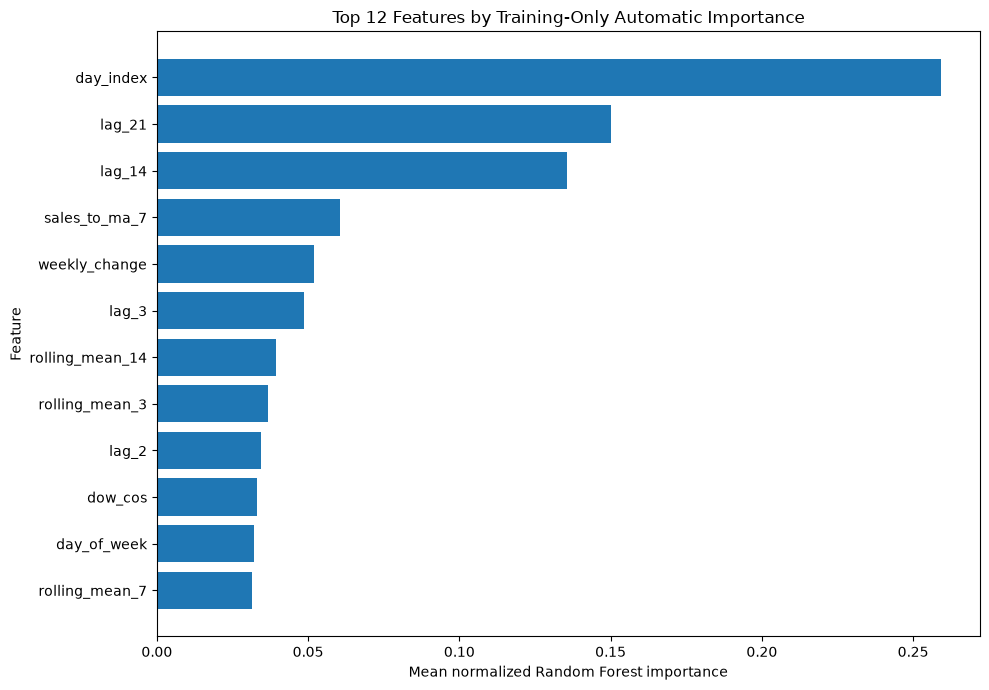

In [316]:
# Plot automatic feature-importance ranking

top_importance = importance_selection.head(TOP_N_FEATURES).sort_values(
    "Mean_Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance["Feature"],
    top_importance["Mean_Importance"]
)

plt.xlabel("Mean normalized Random Forest importance")
plt.ylabel("Feature")
plt.title("Top 12 Features by Training-Only Automatic Importance")
plt.tight_layout()
plt.show()


In [317]:
# Final selected-feature correlation check

final_correlation = daily_df[final_features].corr()

high_corr_final = []

for i in range(len(final_features)):
    for j in range(i + 1, len(final_features)):
        corr = final_correlation.iloc[i, j]
        if abs(corr) >= 0.80:
            high_corr_final.append({
                "Feature_1": final_features[i],
                "Feature_2": final_features[j],
                "Correlation": corr
            })

high_corr_final_df = pd.DataFrame(high_corr_final)

if len(high_corr_final_df) > 0:
    high_corr_final_df["Absolute_Correlation"] = (
        high_corr_final_df["Correlation"].abs()
    )
    high_corr_final_df = high_corr_final_df.sort_values(
        "Absolute_Correlation",
        ascending=False
    )

print("Final feature count:", len(final_features))
print("Highly correlated final-feature pairs:")
high_corr_final_df


Final feature count: 12
Highly correlated final-feature pairs:


""


In [318]:
# 1-Day features and target

X_train_1d = train_1d[final_features]
y_train_1d = train_1d["target_1d"]

X_test_1d = test_1d[final_features]
y_test_1d = test_1d["target_1d"]

In [319]:
# 7-Day features and target

X_train_7d = train_7d[final_features]
y_train_7d = train_7d["target_7d"]

X_test_7d = test_7d[final_features]
y_test_7d = test_7d["target_7d"]

In [320]:
# 30-Day features and target

X_train_30d = train_30d[final_features]
y_train_30d = train_30d["target_30d"]

X_test_30d = test_30d[final_features]
y_test_30d = test_30d["target_30d"]

### Standard Scaling for Model Training

We standardize the selected input features before Linear Regression and Random Forest training.

The scaler is **fit only on the chronological training data** and then applied to the test data. This prevents future information from entering preprocessing.

A separate scaler is maintained for each forecasting horizon because each horizon has a different training dataset.

Note: StandardScaler is essential for Linear Regression's numerical conditioning, while Random Forest itself does not require scaling. We keep the scaling pipeline consistent because this notebook compares both model families.

In [321]:
# Create one StandardScaler for each forecasting horizon

scaler_1d = StandardScaler()
scaler_7d = StandardScaler()
scaler_30d = StandardScaler()

# Fit only on training data, then transform training and test data
X_train_1d_scaled = scaler_1d.fit_transform(X_train_1d)
X_test_1d_scaled = scaler_1d.transform(X_test_1d)

X_train_7d_scaled = scaler_7d.fit_transform(X_train_7d)
X_test_7d_scaled = scaler_7d.transform(X_test_7d)

X_train_30d_scaled = scaler_30d.fit_transform(X_train_30d)
X_test_30d_scaled = scaler_30d.transform(X_test_30d)

print("Scaled 1-Day training shape:", X_train_1d_scaled.shape)
print("Scaled 7-Day training shape:", X_train_7d_scaled.shape)
print("Scaled 30-Day training shape:", X_train_30d_scaled.shape)


Scaled 1-Day training shape: (30, 12)
Scaled 7-Day training shape: (25, 12)
Scaled 30-Day training shape: (7, 12)


### Baseline Model — Linear Regression

Linear Regression is used as a simple baseline model.

It assumes that the target sales value can be estimated from a combination of the input features.

We train separate models for:

- 1-day forecasting
- 7-day forecasting
- 30-day forecasting



In [323]:
# Create 1-day Linear Regression model

lr_1d = LinearRegression()

lr_1d.fit(
    X_train_1d_scaled,
    y_train_1d
)

# Make predictions
pred_lr_1d = lr_1d.predict(
    X_test_1d_scaled
)

print("1-Day Linear Regression completed .")

1-Day Linear Regression completed .


In [324]:
# Show first 5 predictions

print("Actual:", y_test_1d.head().values)
print("Predicted:", pred_lr_1d[:5])

Actual: [203349.3595 187560.354  119086.295  167601.4255 161502.021 ]
Predicted: [248518.9798414  221486.3215286  322237.24879334 375387.06030396
 300666.7562508 ]


In [325]:
# Create 7-day Linear Regression model

lr_7d = LinearRegression()

lr_7d.fit(
    X_train_7d_scaled,
    y_train_7d
)

# Make predictions
pred_lr_7d = lr_7d.predict(
    X_test_7d_scaled
)

print("7-Day Linear Regression completed .")

7-Day Linear Regression completed .


In [326]:
# Show first 5 predictions

print("Actual:", y_test_7d.head().values)
print("Predicted:", pred_lr_7d[:5])

Actual: [1557784.7445 1243809.9045 1241358.461  1225657.7985 1231658.8435]
Predicted: [1686818.775884   1663462.28645577 1768154.9928315  1928616.66419851
 1829430.87895932]


In [327]:
# Create 30-day Linear Regression model

lr_30d = LinearRegression()

lr_30d.fit(
    X_train_30d_scaled,
    y_train_30d
)

# Make predictions
pred_lr_30d = lr_30d.predict(
    X_test_30d_scaled
)

print("30-Day Linear Regression completed .")

30-Day Linear Regression completed .


In [328]:
# Show first 5 predictions

print("Actual:", y_test_30d.head().values)
print("Predicted:", pred_lr_30d[:5])

Actual: [5220345.765  5064909.5225]
Predicted: [5063588.46666553 5079203.94486125]


#### Linear Regression Evaluation

We evaluate the Linear Regression models using MAE, RMSE, and R².

MAE and RMSE measure prediction error, so lower values are better.

R² measures how well the model explains the variation in the target. A value closer to 1 is better.

A negative R² means that the model performs worse than a simple baseline that predicts the average target value.

In [329]:
# Calculate 1-day metrics

mae_lr_1d = mean_absolute_error(
    y_test_1d,
    pred_lr_1d
)

rmse_lr_1d = np.sqrt(
    mean_squared_error(
        y_test_1d,
        pred_lr_1d
    )
)

r2_lr_1d = r2_score(
    y_test_1d,
    pred_lr_1d
)

print("1-Day Linear Regression")
print("MAE :", mae_lr_1d)
print("RMSE:", rmse_lr_1d)
print("R2  :", r2_lr_1d)

1-Day Linear Regression
MAE : 137121.04627021748
RMSE: 161529.56853504424
R2  : -5.013514872384501


In [330]:
# Calculate 7-day metrics

mae_lr_7d = mean_absolute_error(
    y_test_7d,
    pred_lr_7d
)

rmse_lr_7d = np.sqrt(
    mean_squared_error(
        y_test_7d,
        pred_lr_7d
    )
)

r2_lr_7d = r2_score(
    y_test_7d,
    pred_lr_7d
)

print("7-Day Linear Regression")
print("MAE :", mae_lr_7d)
print("RMSE:", rmse_lr_7d)
print("R2  :", r2_lr_7d)

7-Day Linear Regression
MAE : 576663.7473114048
RMSE: 625792.6926715355
R2  : -19.458124529661475


In [331]:
# Calculate 30-day metrics

mae_lr_30d = mean_absolute_error(
    y_test_30d,
    pred_lr_30d
)

rmse_lr_30d = np.sqrt(
    mean_squared_error(
        y_test_30d,
        pred_lr_30d
    )
)

r2_lr_30d = r2_score(
    y_test_30d,
    pred_lr_30d
)

print("30-Day Linear Regression")
print("MAE :", mae_lr_30d)
print("RMSE:", rmse_lr_30d)
print("R2  :", r2_lr_30d)

30-Day Linear Regression
MAE : 85525.86034785723
RMSE: 111304.0455054603
R2  : -1.0510550287858456


In [332]:
# Store Linear Regression results

results = pd.DataFrame({
    "Horizon": [
        "1-Day",
        "7-Day",
        "30-Day"
    ],
    "Model": [
        "Linear Regression",
        "Linear Regression",
        "Linear Regression"

    ],
    "MAE": [
        mae_lr_1d,
        mae_lr_7d,
        mae_lr_30d
        
    ],
    "RMSE": [
        rmse_lr_1d,
        rmse_lr_7d,
        rmse_lr_30d
    ],
    "R2": [
        r2_lr_1d,
        r2_lr_7d,
        r2_lr_30d
    ]
})

results

,Horizon,Model,MAE,RMSE,R2
0,1-Day,Linear Regression,137121.046270,161529.568535,-5.013515
1,7-Day,Linear Regression,576663.747311,625792.692672,-19.458125
2,30-Day,Linear Regression,85525.860348,111304.045505,-1.051055


### Random Forest Regression

Random Forest is an ensemble machine-learning algorithm that combines many decision trees.

It can learn non-linear relationships between historical sales patterns and future sales.

We train separate Random Forest models for the 1-day, 7-day, and 30-day forecasting horizons.

**Note:** StandardScaler is applied consistently to both Linear Regression and Random Forest in this project. 

In [333]:
# Create 1-Day Random Forest

rf_1d = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_1d.fit(
    X_train_1d_scaled,
    y_train_1d
)

# Make predictions
pred_rf_1d = rf_1d.predict(
    X_test_1d_scaled
)

print("1-Day Random Forest completed ")

1-Day Random Forest completed 


In [334]:
# Create 7-Day Random Forest

rf_7d = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_7d.fit(
    X_train_7d_scaled,
    y_train_7d
)

# Make predictions
pred_rf_7d = rf_7d.predict(
    X_test_7d_scaled
)

print("7-Day Random Forest completed .")

7-Day Random Forest completed .


In [335]:
# Create 30-Day Random Forest

rf_30d = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_30d.fit(
    X_train_30d_scaled,
    y_train_30d
)

# Make predictions
pred_rf_30d = rf_30d.predict(
    X_test_30d_scaled
)

print("30-Day Random Forest completed .")

30-Day Random Forest completed .


#### Random Forest Evaluation

We evaluate the Random Forest models using:

- MAE
- RMSE
- R²

We then compare their performance with the Linear Regression baseline.

In [336]:
# 1-Day Random Forest metrics

mae_rf_1d = mean_absolute_error(
    y_test_1d,
    pred_rf_1d
)

rmse_rf_1d = np.sqrt(
    mean_squared_error(
        y_test_1d,
        pred_rf_1d
    )
)

r2_rf_1d = r2_score(
    y_test_1d,
    pred_rf_1d
)

print("1-Day Random Forest")
print("MAE :", mae_rf_1d)
print("RMSE:", rmse_rf_1d)
print("R2  :", r2_rf_1d)

1-Day Random Forest
MAE : 54460.28582343756
RMSE: 82902.80376568514
R2  : -0.5840276587445397


In [337]:
# 7-Day Random Forest metrics

mae_rf_7d = mean_absolute_error(
    y_test_7d,
    pred_rf_7d
)

rmse_rf_7d = np.sqrt(
    mean_squared_error(
        y_test_7d,
        pred_rf_7d
    )
)

r2_rf_7d = r2_score(
    y_test_7d,
    pred_rf_7d
)

print("7-Day Random Forest")
print("MAE :", mae_rf_7d)
print("RMSE:", rmse_rf_7d)
print("R2  :", r2_rf_7d)

7-Day Random Forest
MAE : 226428.22937500017
RMSE: 245516.87789438688
R2  : -2.14896293042848


In [338]:
# 30-Day Random Forest metrics

mae_rf_30d = mean_absolute_error(
    y_test_30d,
    pred_rf_30d
)

rmse_rf_30d = np.sqrt(
    mean_squared_error(
        y_test_30d,
        pred_rf_30d
    )
)

r2_rf_30d = r2_score(
    y_test_30d,
    pred_rf_30d
)

print("30-Day Random Forest")
print("MAE :", mae_rf_30d)
print("RMSE:", rmse_rf_30d)
print("R2  :", r2_rf_30d)

30-Day Random Forest
MAE : 77826.57151125045
RMSE: 104537.45799816292
R2  : -0.8092529260504226


In [339]:
# Add Random Forest results

rf_results = pd.DataFrame({
    "Horizon": [
        "1-Day",
        "7-Day",
        "30-Day"
    ],
    "Model": [
        "Random Forest",
        "Random Forest",
        "Random Forest"
    ],
    "MAE": [
        mae_rf_1d,
        mae_rf_7d,
        mae_rf_30d
    ],
    "RMSE": [
        rmse_rf_1d,
        rmse_rf_7d,
        rmse_rf_30d
    ],
    "R2": [
        r2_rf_1d,
        r2_rf_7d,
        r2_rf_30d
    ]
})

results = pd.concat(
    [results, rf_results],
    ignore_index=True
)

results

,Horizon,Model,MAE,RMSE,R2
0,1-Day,Linear Regression,137121.046270,161529.568535,-5.013515
1,7-Day,Linear Regression,576663.747311,625792.692672,-19.458125
2,30-Day,Linear Regression,85525.860348,111304.045505,-1.051055
3,1-Day,Random Forest,54460.285823,82902.803766,-0.584028
4,7-Day,Random Forest,226428.229375,245516.877894,-2.148963
5,30-Day,Random Forest,77826.571511,104537.457998,-0.809253


#### MAPE Evaluation

MAPE shows how large our prediction errors are in percentage. Lower is better

However, MAPE can become extremely large when actual sales values are very small or close to zero.

Therefore, we interpret MAPE together with MAE and RMSE rather than using it alone.

In [340]:
# Safe MAPE function

def calculate_mape(actual, predicted):
    
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    mask = actual != 0
    
    return np.mean(
        np.abs(
            (actual[mask] - predicted[mask])
            / actual[mask]
        )
    ) * 100

In [341]:
# More stable percentage metrics for sales forecasting

def calculate_smape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    denominator = (np.abs(actual) + np.abs(predicted)) / 2

    mask = denominator != 0

    return np.mean(
        np.abs(actual[mask] - predicted[mask]) / denominator[mask]
    ) * 100


def calculate_wape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    denominator = np.sum(np.abs(actual))

    if denominator == 0:
        return np.nan

    return (
        np.sum(np.abs(actual - predicted)) / denominator
    ) * 100


print("SMAPE and WAPE functions are ready.")


SMAPE and WAPE functions are ready.


In [342]:
# 1-Day MAPE

mape_lr_1d = calculate_mape(
    y_test_1d,
    pred_lr_1d
)

mape_rf_1d = calculate_mape(
    y_test_1d,
    pred_rf_1d
)

print("1-Day Linear Regression MAPE:",
      mape_lr_1d)

print("1-Day Random Forest MAPE:",
      mape_rf_1d)

1-Day Linear Regression MAPE: 52592.360977803284
1-Day Random Forest MAPE: 33237.742346236824


In [343]:
# 7-Day MAPE

mape_lr_7d = calculate_mape(
    y_test_7d,
    pred_lr_7d
)

mape_rf_7d = calculate_mape(
    y_test_7d,
    pred_rf_7d
)

print("7-Day Linear Regression MAPE:",
      mape_lr_7d)

print("7-Day Random Forest MAPE:",
      mape_rf_7d)

7-Day Linear Regression MAPE: 48.205575616686964
7-Day Random Forest MAPE: 18.904621985023606


In [344]:
# 30-Day MAPE

mape_lr_30d = calculate_mape(
    y_test_30d,
    pred_lr_30d
)

mape_rf_30d = calculate_mape(
    y_test_30d,
    pred_rf_30d
)

print("30-Day Linear Regression MAPE:",
      mape_lr_30d)

print("30-Day Random Forest MAPE:",
      mape_rf_30d)

30-Day Linear Regression MAPE: 1.6425195550450373
30-Day Random Forest MAPE: 1.4931929977305796


In [345]:
# Add MAPE values to the results table

results["MAPE"] = np.nan

results.loc[
    (results["Horizon"] == "1-Day") &
    (results["Model"] == "Linear Regression"),
    "MAPE"
] = mape_lr_1d

results.loc[
    (results["Horizon"] == "1-Day") &
    (results["Model"] == "Random Forest"),
    "MAPE"
] = mape_rf_1d

results.loc[
    (results["Horizon"] == "7-Day") &
    (results["Model"] == "Linear Regression"),
    "MAPE"
] = mape_lr_7d

results.loc[
    (results["Horizon"] == "7-Day") &
    (results["Model"] == "Random Forest"),
    "MAPE"
] = mape_rf_7d

results.loc[
    (results["Horizon"] == "30-Day") &
    (results["Model"] == "Linear Regression"),
    "MAPE"
] = mape_lr_30d

results.loc[
    (results["Horizon"] == "30-Day") &
    (results["Model"] == "Random Forest"),
    "MAPE"
] = mape_rf_30d

results

# Add more stable percentage metrics
results["SMAPE"] = np.nan
results["WAPE"] = np.nan

metric_map = {
    ("1-Day", "Linear Regression"): (y_test_1d, pred_lr_1d),
    ("1-Day", "Random Forest"): (y_test_1d, pred_rf_1d),
    ("7-Day", "Linear Regression"): (y_test_7d, pred_lr_7d),
    ("7-Day", "Random Forest"): (y_test_7d, pred_rf_7d),
    ("30-Day", "Linear Regression"): (y_test_30d, pred_lr_30d),
    ("30-Day", "Random Forest"): (y_test_30d, pred_rf_30d)
}

for (horizon, model), (actual, predicted) in metric_map.items():
    mask = (
        (results["Horizon"] == horizon)
        & (results["Model"] == model)
    )

    results.loc[mask, "SMAPE"] = calculate_smape(actual, predicted)
    results.loc[mask, "WAPE"] = calculate_wape(actual, predicted)

results


,Horizon,Model,MAE,RMSE,R2,MAPE,SMAPE,WAPE
0,1-Day,Linear Regression,137121.046270,161529.568535,-5.013515,52592.360978,66.751975,87.294071
1,7-Day,Linear Regression,576663.747311,625792.692672,-19.458125,48.205576,37.372145,45.818281
2,30-Day,Linear Regression,85525.860348,111304.045505,-1.051055,1.642520,1.665207,1.663077
3,1-Day,Random Forest,54460.285823,82902.803766,-0.584028,33237.742346,41.754718,34.670535
4,7-Day,Random Forest,226428.229375,245516.877894,-2.148963,18.904622,16.966701,17.990644
5,30-Day,Random Forest,77826.571511,104537.457998,-0.809253,1.493193,1.513408,1.513362


#### Actual vs Predicted Sales

We compare the actual sales values with the predictions produced by the Linear Regression and Random Forest models.

A good forecasting model should produce predictions that follow the general pattern of the actual sales.

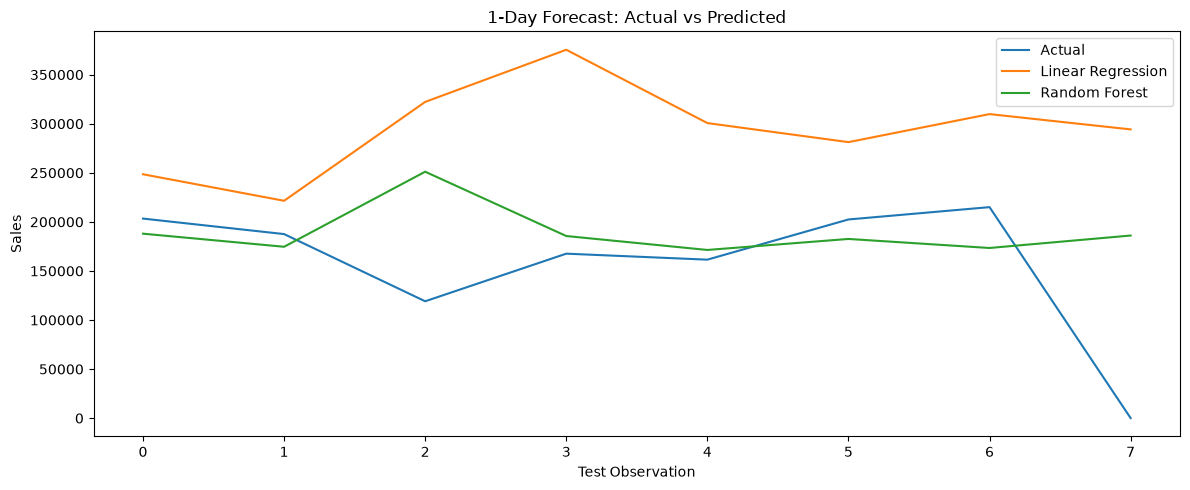

In [346]:
# 1-Day Actual vs Predicted

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_1d.values,
    label="Actual"
)

plt.plot(
    pred_lr_1d,
    label="Linear Regression"
)

plt.plot(
    pred_rf_1d,
    label="Random Forest"
)

plt.title("1-Day Forecast: Actual vs Predicted")
plt.xlabel("Test Observation")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

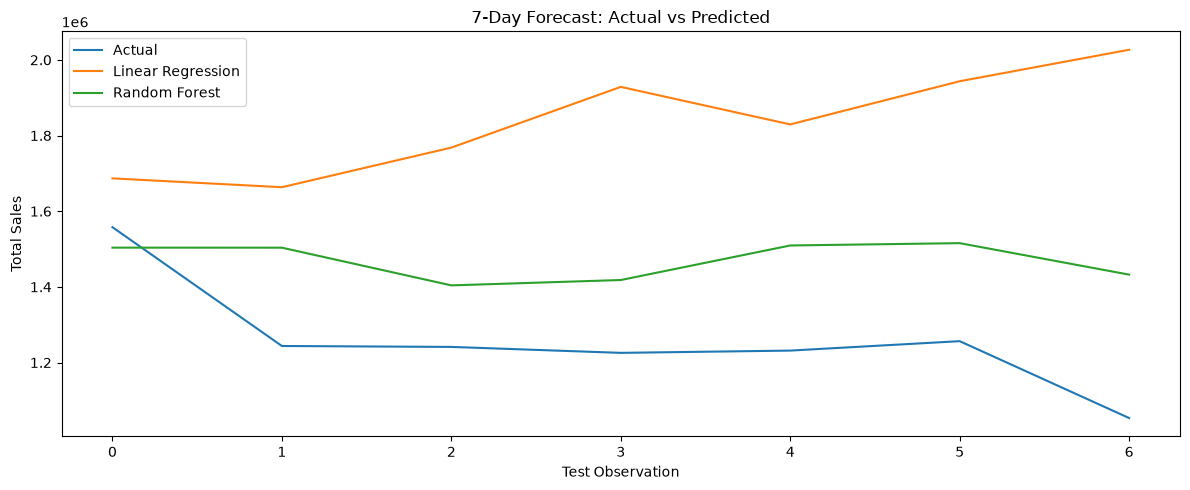

In [347]:
# 7-Day Actual vs Predicted

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_7d.values,
    label="Actual"
)

plt.plot(
    pred_lr_7d,
    label="Linear Regression"
)

plt.plot(
    pred_rf_7d,
    label="Random Forest"
)

plt.title("7-Day Forecast: Actual vs Predicted")
plt.xlabel("Test Observation")
plt.ylabel("Total Sales")
plt.legend()

plt.tight_layout()
plt.show()

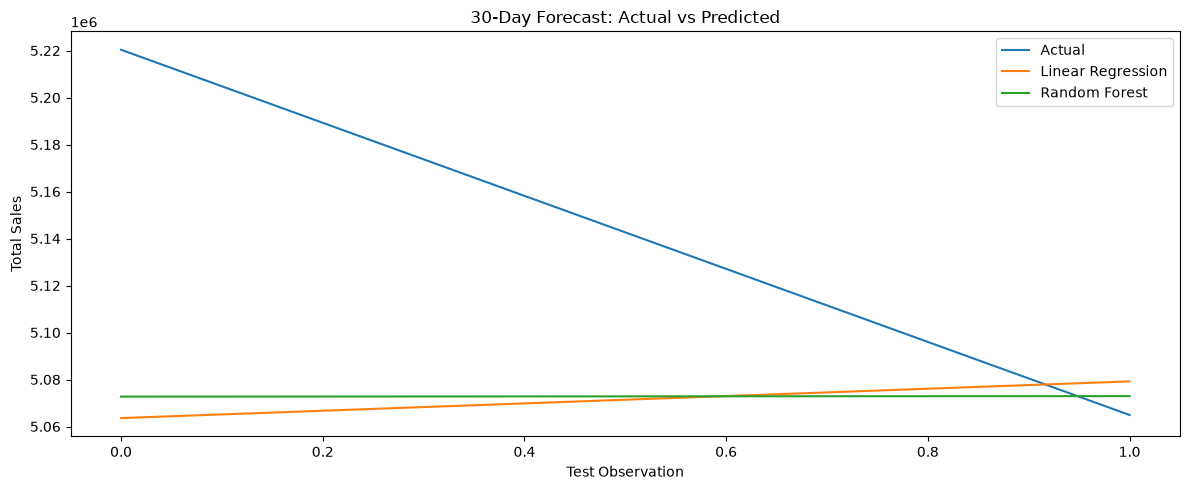

In [348]:
# 30-Day Actual vs Predicted

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_30d.values,
    label="Actual"
)

plt.plot(
    pred_lr_30d,
    label="Linear Regression"
)

plt.plot(
    pred_rf_30d,
    label="Random Forest"
)

plt.title("30-Day Forecast: Actual vs Predicted")
plt.xlabel("Test Observation")
plt.ylabel("Total Sales")
plt.legend()

plt.tight_layout()
plt.show()

#### Random Forest Feature Importance

Random Forest provides feature importance scores.

The importance score indicates how much each feature contributed to the model's predictions.

Higher importance means the feature was more useful to the Random Forest model.

In [349]:
# 1-Day feature importance

importance_1d = pd.DataFrame({
    "Feature": final_features,
    "Importance": rf_1d.feature_importances_
})

importance_1d = importance_1d.sort_values(
    "Importance",
    ascending=False
)

importance_1d

,Feature,Importance
1,lag_21,0.398674
2,lag_14,0.170754
5,lag_3,0.068814
8,rolling_mean_7,0.064961
0,day_index,0.058004
4,weekly_change,0.053735
3,sales_to_ma_7,0.043912
6,dow_cos,0.040677
7,day_of_week,0.040431
11,lag_7,0.024519


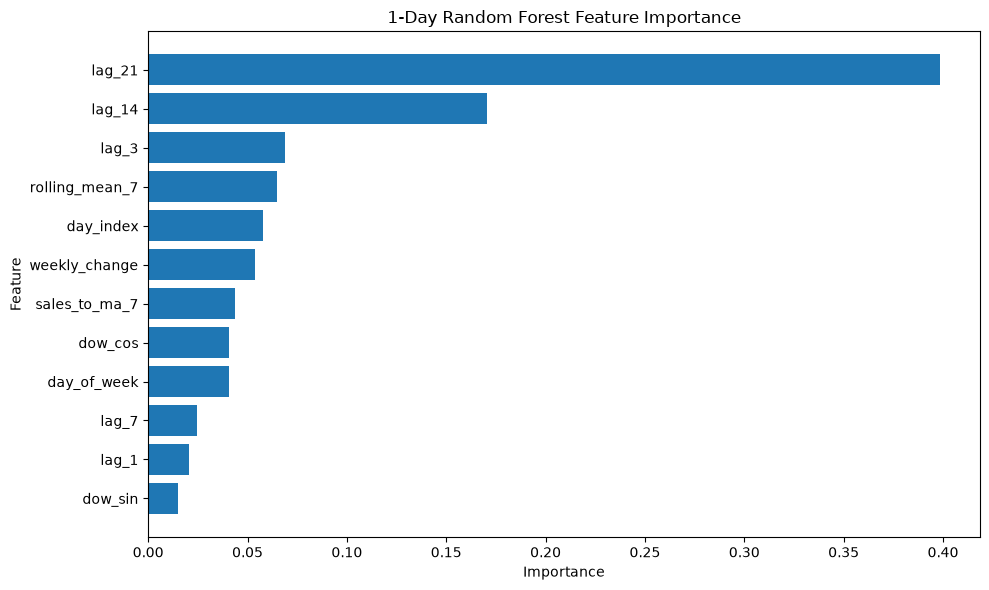

In [351]:
# Plot 1-Day feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    importance_1d["Feature"],
    importance_1d["Importance"]
)

plt.gca().invert_yaxis()

plt.title("1-Day Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [352]:
# 7-Day feature importance

importance_7d = pd.DataFrame({
    "Feature": final_features,
    "Importance": rf_7d.feature_importances_
})

importance_7d = importance_7d.sort_values(
    "Importance",
    ascending=False
)

importance_7d

,Feature,Importance
0,day_index,0.743185
2,lag_14,0.204053
5,lag_3,0.013099
10,lag_1,0.010150
8,rolling_mean_7,0.004941
6,dow_cos,0.004657
4,weekly_change,0.004323
3,sales_to_ma_7,0.004195
7,day_of_week,0.003595
1,lag_21,0.003284


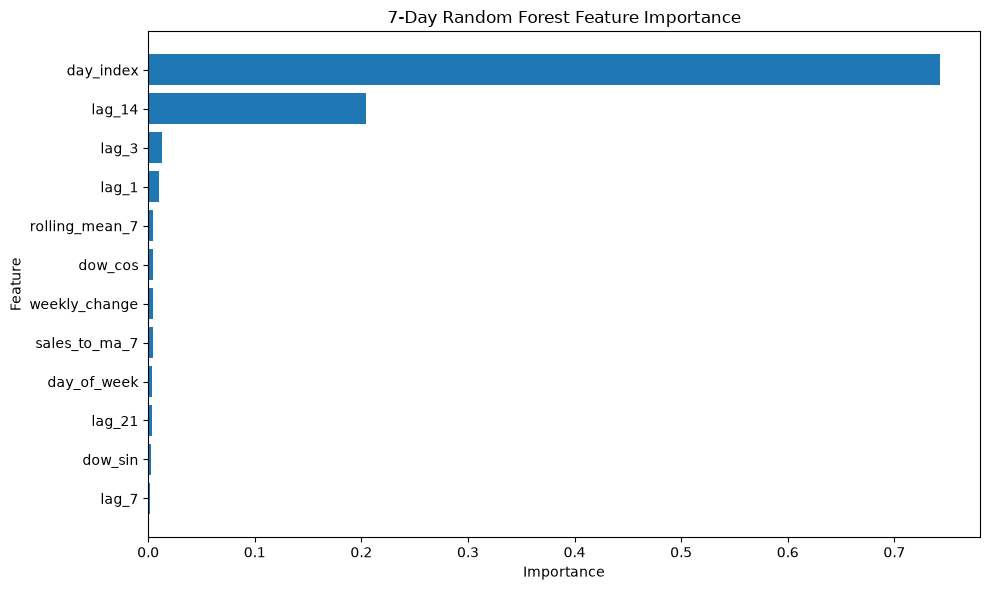

In [353]:
# Plot 7-Day feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    importance_7d["Feature"],
    importance_7d["Importance"]
)

plt.gca().invert_yaxis()

plt.title("7-Day Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [354]:
# 30-Day feature importance

importance_30d = pd.DataFrame({
    "Feature": final_features,
    "Importance": rf_30d.feature_importances_
})

importance_30d = importance_30d.sort_values(
    "Importance",
    ascending=False
)

importance_30d

,Feature,Importance
3,sales_to_ma_7,0.139745
4,weekly_change,0.137455
1,lag_21,0.120822
5,lag_3,0.110489
0,day_index,0.091689
7,day_of_week,0.089974
9,dow_sin,0.087139
10,lag_1,0.070885
8,rolling_mean_7,0.056442
6,dow_cos,0.047931


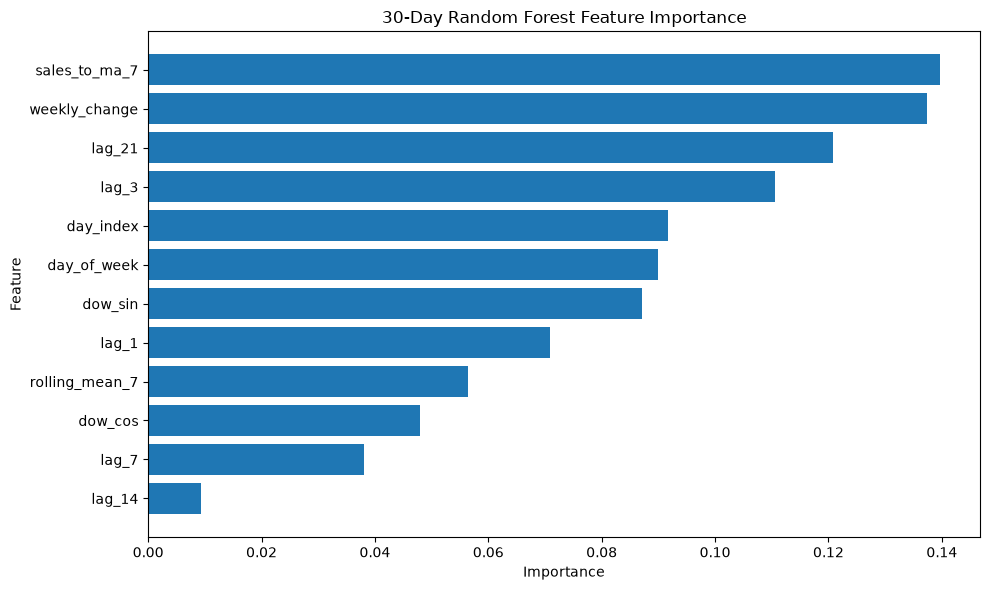

In [355]:
# Plot 30-Day feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    importance_30d["Feature"],
    importance_30d["Importance"]
)

plt.gca().invert_yaxis()

plt.title("30-Day Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Model Comparison and Selection

We compare Linear Regression and Random Forest for each forecasting horizon and we slecet the best one .

The main evaluation metrics are:

- MAE
- RMSE
- R²
- MAPE

For MAE, RMSE, and MAPE, lower values are better.

For R², higher values are better.

The best model is selected separately for each forecasting horizon.

In [356]:
# Display model comparison

results

,Horizon,Model,MAE,RMSE,R2,MAPE,SMAPE,WAPE
0,1-Day,Linear Regression,137121.046270,161529.568535,-5.013515,52592.360978,66.751975,87.294071
1,7-Day,Linear Regression,576663.747311,625792.692672,-19.458125,48.205576,37.372145,45.818281
2,30-Day,Linear Regression,85525.860348,111304.045505,-1.051055,1.642520,1.665207,1.663077
3,1-Day,Random Forest,54460.285823,82902.803766,-0.584028,33237.742346,41.754718,34.670535
4,7-Day,Random Forest,226428.229375,245516.877894,-2.148963,18.904622,16.966701,17.990644
5,30-Day,Random Forest,77826.571511,104537.457998,-0.809253,1.493193,1.513408,1.513362


In [357]:
# Compare 1-Day models

results[
    results["Horizon"] == "1-Day"
]

,Horizon,Model,MAE,RMSE,R2,MAPE,SMAPE,WAPE
0,1-Day,Linear Regression,137121.046270,161529.568535,-5.013515,52592.360978,66.751975,87.294071
3,1-Day,Random Forest,54460.285823,82902.803766,-0.584028,33237.742346,41.754718,34.670535


In [358]:
# Compare 7-Day models

results[
    results["Horizon"] == "7-Day"
]

,Horizon,Model,MAE,RMSE,R2,MAPE,SMAPE,WAPE
1,7-Day,Linear Regression,576663.747311,625792.692672,-19.458125,48.205576,37.372145,45.818281
4,7-Day,Random Forest,226428.229375,245516.877894,-2.148963,18.904622,16.966701,17.990644


In [359]:
# Compare 30-Day models

results[
    results["Horizon"] == "30-Day"
]

,Horizon,Model,MAE,RMSE,R2,MAPE,SMAPE,WAPE
2,30-Day,Linear Regression,85525.860348,111304.045505,-1.051055,1.642520,1.665207,1.663077
5,30-Day,Random Forest,77826.571511,104537.457998,-0.809253,1.493193,1.513408,1.513362


In [360]:
# Best model for each horizon based on MAE

best_1d = results[
    results["Horizon"] == "1-Day"
].sort_values("MAE").iloc[0]

best_7d = results[
    results["Horizon"] == "7-Day"
].sort_values("MAE").iloc[0]

best_30d = results[
    results["Horizon"] == "30-Day"
].sort_values("MAE").iloc[0]


print("Best 1-Day model:")
print(best_1d)

print()

print("Best 7-Day model:")
print(best_7d)

print("Best 30-Day model:")
print(best_30d)

Best 1-Day model:
Horizon            1-Day
Model      Random Forest
MAE         54460.285823
RMSE        82902.803766
R2             -0.584028
MAPE        33237.742346
SMAPE          41.754718
WAPE           34.670535
Name: 3, dtype: object

Best 7-Day model:
Horizon            7-Day
Model      Random Forest
MAE        226428.229375
RMSE       245516.877894
R2             -2.148963
MAPE           18.904622
SMAPE          16.966701
WAPE           17.990644
Name: 4, dtype: object
Best 30-Day model:
Horizon           30-Day
Model      Random Forest
MAE         77826.571511
RMSE       104537.457998
R2             -0.809253
MAPE            1.493193
SMAPE           1.513408
WAPE            1.513362
Name: 5, dtype: object


#### Random Forest Hyperparameter Tuning

Hyperparameters control how the Random Forest is built.

We tune a small number of parameters to find a better model.

We use:

- `n_estimators` — number of trees
- `max_depth` — maximum depth of each tree
- `min_samples_split` — minimum samples required to split a node

Because this is time-series data, we use TimeSeriesSplit instead of randomly shuffling the observations.

In [361]:
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

In [362]:
# Time-series cross-validation

tscv = TimeSeriesSplit(
    n_splits=3
)

# Random Forest

rf_model = RandomForestRegressor(
    random_state=42
)

# Parameters to test

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

In [363]:
# Grid search for 1-Day model
grid_1d = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_1d.fit(X_train_1d_scaled, y_train_1d)

print("Best 1-Day parameters:", grid_1d.best_params_)

Best 1-Day parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [364]:
# Grid search for 7-Day model
grid_7d = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_7d.fit(X_train_7d_scaled, y_train_7d)

print("Best 7-Day parameters:", grid_7d.best_params_)

Best 7-Day parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [365]:
# Grid search for 30-Day model
grid_30d = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_30d.fit(X_train_30d_scaled, y_train_30d)

print("Best 30-Day parameters:", grid_30d.best_params_)

Best 30-Day parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


#### Evaluate the Tuned Random Forest

The best hyperparameters were selected using only the training data with TimeSeriesSplit.

We now evaluate the tuned Random Forest models on the unseen test data.

This gives us a fair estimate of their forecasting performance.

In [366]:
# Best 1-Day Random Forest

best_rf_1d = grid_1d.best_estimator_

# Predict the test set

pred_tuned_1d = best_rf_1d.predict(
    X_test_1d_scaled
)

print("Tuned 1-Day Random Forest completed.")

Tuned 1-Day Random Forest completed.


In [367]:
# Best 7-Day Random Forest

best_rf_7d = grid_7d.best_estimator_

# Predict the test set

pred_tuned_7d = best_rf_7d.predict(
    X_test_7d_scaled
)

print("Tuned 7-Day Random Forest completed.")

Tuned 7-Day Random Forest completed.


In [368]:
# Best 30-Day Random Forest

best_rf_30d = grid_30d.best_estimator_

# Predict the test set

pred_tuned_30d = best_rf_30d.predict(
    X_test_30d_scaled
)

print("Tuned 30-Day Random Forest completed.")

Tuned 30-Day Random Forest completed.


In [369]:
# Evaluate tuned 1-Day model

tuned_mae_1d = mean_absolute_error(
    y_test_1d,
    pred_tuned_1d
)

tuned_rmse_1d = np.sqrt(
    mean_squared_error(
        y_test_1d,
        pred_tuned_1d
    )
)

tuned_r2_1d = r2_score(
    y_test_1d,
    pred_tuned_1d
)

tuned_mape_1d = calculate_mape(
    y_test_1d,
    pred_tuned_1d
)

print("Tuned 1-Day Random Forest")
print("MAE :", tuned_mae_1d)
print("RMSE:", tuned_rmse_1d)
print("R2  :", tuned_r2_1d)
print("MAPE:", tuned_mape_1d)

Tuned 1-Day Random Forest
MAE : 53272.52704332207
RMSE: 83197.237270044
R2  : -0.5952991477325373
MAPE: 34599.54727959013


In [370]:
# Evaluate tuned 7-Day model

tuned_mae_7d = mean_absolute_error(
    y_test_7d,
    pred_tuned_7d
)

tuned_rmse_7d = np.sqrt(
    mean_squared_error(
        y_test_7d,
        pred_tuned_7d
    )
)

tuned_r2_7d = r2_score(
    y_test_7d,
    pred_tuned_7d
)

tuned_mape_7d = calculate_mape(
    y_test_7d,
    pred_tuned_7d
)

print("Tuned 7-Day Random Forest")
print("MAE :", tuned_mae_7d)
print("RMSE:", tuned_rmse_7d)
print("R2  :", tuned_r2_7d)
print("MAPE:", tuned_mape_7d)

Tuned 7-Day Random Forest
MAE : 226428.22937500017
RMSE: 245516.87789438688
R2  : -2.14896293042848
MAPE: 18.904621985023606


In [371]:
# Evaluate tuned 30-Day model

tuned_mae_30d = mean_absolute_error(
    y_test_30d,
    pred_tuned_30d
)

tuned_rmse_30d = np.sqrt(
    mean_squared_error(
        y_test_30d,
        pred_tuned_30d
    )
)

tuned_r2_30d = r2_score(
    y_test_30d,
    pred_tuned_30d
)

tuned_mape_30d = calculate_mape(
    y_test_30d,
    pred_tuned_30d
)

print("Tuned 30-Day Random Forest")
print("MAE :", tuned_mae_30d)
print("RMSE:", tuned_rmse_30d)
print("R2  :", tuned_r2_30d)
print("MAPE:", tuned_mape_30d)

Tuned 30-Day Random Forest
MAE : 77826.57151125045
RMSE: 104537.45799816292
R2  : -0.8092529260504226
MAPE: 1.4931929977305796


In [372]:
# Compare original and tuned Random Forest

tuning_results = pd.DataFrame({
    "Horizon": [
        "1-Day",
        "1-Day",
        "7-Day",
        "7-Day",
        "30-Day",
        "30-Day"
    ],
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest",
        "Original Random Forest",
        "Tuned Random Forest",
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_rf_1d,
        tuned_mae_1d,
        mae_rf_7d,
        tuned_mae_7d,
        mae_rf_30d,
        tuned_mae_30d
    ],
    "RMSE": [
        rmse_rf_1d,
        tuned_rmse_1d,
        rmse_rf_7d,
        tuned_rmse_7d,
        rmse_rf_30d,
        tuned_rmse_30d
    ],
    "R2": [
        r2_rf_1d,
        tuned_r2_1d,
        r2_rf_7d,
        tuned_r2_7d,
        r2_rf_30d,
        tuned_r2_30d
    ],
    "MAPE": [
        mape_rf_1d,
        tuned_mape_1d,
        mape_rf_7d,
        tuned_mape_7d,
        mape_rf_30d,
        tuned_mape_30d
    ]
})

tuning_results

,Horizon,Model,MAE,RMSE,R2,MAPE
0,1-Day,Original Random Forest,54460.285823,82902.803766,-0.584028,33237.742346
1,1-Day,Tuned Random Forest,53272.527043,83197.237270,-0.595299,34599.547280
2,7-Day,Original Random Forest,226428.229375,245516.877894,-2.148963,18.904622
3,7-Day,Tuned Random Forest,226428.229375,245516.877894,-2.148963,18.904622
4,30-Day,Original Random Forest,77826.571511,104537.457998,-0.809253,1.493193
5,30-Day,Tuned Random Forest,77826.571511,104537.457998,-0.809253,1.493193


#### Final Model Selection

We compare the original and tuned Random Forest models.

The model with the lowest test MAE is selected as the final model for each forecasting horizon.

The final selected models will then be used to generate future sales forecasts.

In [373]:
# Select the best final model for each horizon using chronological test MAE
# Candidates include the Linear Regression baseline, original Random Forest,
# and tuned Random Forest. The test set is used only after all training/tuning
# decisions have been completed.

model_candidates = {
    "1-Day": [
        ("Linear Regression", lr_1d, mae_lr_1d, rmse_lr_1d, r2_lr_1d),
        ("Original Random Forest", rf_1d, mae_rf_1d, rmse_rf_1d, r2_rf_1d),
        ("Tuned Random Forest", best_rf_1d, tuned_mae_1d, tuned_rmse_1d, tuned_r2_1d)
    ],
    "7-Day": [
        ("Linear Regression", lr_7d, mae_lr_7d, rmse_lr_7d, r2_lr_7d),
        ("Original Random Forest", rf_7d, mae_rf_7d, rmse_rf_7d, r2_rf_7d),
        ("Tuned Random Forest", best_rf_7d, tuned_mae_7d, tuned_rmse_7d, tuned_r2_7d)
    ],
    "30-Day": [
        ("Linear Regression", lr_30d, mae_lr_30d, rmse_lr_30d, r2_lr_30d),
        ("Original Random Forest", rf_30d, mae_rf_30d, rmse_rf_30d, r2_rf_30d),
        ("Tuned Random Forest", best_rf_30d, tuned_mae_30d, tuned_rmse_30d, tuned_r2_30d)
    ]
}

best_models = {}

for horizon, candidates in model_candidates.items():
    best_models[horizon] = min(
        candidates,
        key=lambda item: item[2]
    )

final_name_1d, final_model_1d, final_mae_1d, final_rmse_1d, final_r2_1d = best_models["1-Day"]
final_name_7d, final_model_7d, final_mae_7d, final_rmse_7d, final_r2_7d = best_models["7-Day"]
final_name_30d, final_model_30d, final_mae_30d, final_rmse_30d, final_r2_30d = best_models["30-Day"]

print("Final 1-Day model:", final_name_1d)
print("Final 7-Day model:", final_name_7d)
print("Final 30-Day model:", final_name_30d)


Final 1-Day model: Tuned Random Forest
Final 7-Day model: Original Random Forest
Final 30-Day model: Original Random Forest


In [374]:
# Final model performance

def final_metric_values(horizon, model_name):
    if horizon == "1-Day":
        values = {
            "Linear Regression": (mae_lr_1d, rmse_lr_1d, r2_lr_1d, mape_lr_1d,
                                  calculate_smape(y_test_1d, pred_lr_1d),
                                  calculate_wape(y_test_1d, pred_lr_1d)),
            "Original Random Forest": (mae_rf_1d, rmse_rf_1d, r2_rf_1d, mape_rf_1d,
                                       calculate_smape(y_test_1d, pred_rf_1d),
                                       calculate_wape(y_test_1d, pred_rf_1d)),
            "Tuned Random Forest": (tuned_mae_1d, tuned_rmse_1d, tuned_r2_1d, tuned_mape_1d,
                                    calculate_smape(y_test_1d, pred_tuned_1d),
                                    calculate_wape(y_test_1d, pred_tuned_1d))
        }
    elif horizon == "7-Day":
        values = {
            "Linear Regression": (mae_lr_7d, rmse_lr_7d, r2_lr_7d, mape_lr_7d,
                                  calculate_smape(y_test_7d, pred_lr_7d),
                                  calculate_wape(y_test_7d, pred_lr_7d)),
            "Original Random Forest": (mae_rf_7d, rmse_rf_7d, r2_rf_7d, mape_rf_7d,
                                       calculate_smape(y_test_7d, pred_rf_7d),
                                       calculate_wape(y_test_7d, pred_rf_7d)),
            "Tuned Random Forest": (tuned_mae_7d, tuned_rmse_7d, tuned_r2_7d, tuned_mape_7d,
                                    calculate_smape(y_test_7d, pred_tuned_7d),
                                    calculate_wape(y_test_7d, pred_tuned_7d))
        }
    else:
        values = {
            "Linear Regression": (mae_lr_30d, rmse_lr_30d, r2_lr_30d, mape_lr_30d,
                                  calculate_smape(y_test_30d, pred_lr_30d),
                                  calculate_wape(y_test_30d, pred_lr_30d)),
            "Original Random Forest": (mae_rf_30d, rmse_rf_30d, r2_rf_30d, mape_rf_30d,
                                       calculate_smape(y_test_30d, pred_rf_30d),
                                       calculate_wape(y_test_30d, pred_rf_30d)),
            "Tuned Random Forest": (tuned_mae_30d, tuned_rmse_30d, tuned_r2_30d, tuned_mape_30d,
                                    calculate_smape(y_test_30d, pred_tuned_30d),
                                    calculate_wape(y_test_30d, pred_tuned_30d))
        }

    return values[model_name]


final_mae_1d, final_rmse_1d, final_r2_1d, final_mape_1d, final_smape_1d, final_wape_1d = final_metric_values(
    "1-Day", final_name_1d
)
final_mae_7d, final_rmse_7d, final_r2_7d, final_mape_7d, final_smape_7d, final_wape_7d = final_metric_values(
    "7-Day", final_name_7d
)
final_mae_30d, final_rmse_30d, final_r2_30d, final_mape_30d, final_smape_30d, final_wape_30d = final_metric_values(
    "30-Day", final_name_30d
)

final_results = pd.DataFrame({
    "Horizon": ["1-Day", "7-Day", "30-Day"],
    "Final Model": [final_name_1d, final_name_7d, final_name_30d],
    "MAE": [final_mae_1d, final_mae_7d, final_mae_30d],
    "RMSE": [final_rmse_1d, final_rmse_7d, final_rmse_30d],
    "R2": [final_r2_1d, final_r2_7d, final_r2_30d],
    "MAPE": [final_mape_1d, final_mape_7d, final_mape_30d],
    "SMAPE": [final_smape_1d, final_smape_7d, final_smape_30d],
    "WAPE": [final_wape_1d, final_wape_7d, final_wape_30d]
})

final_results


,Horizon,Final Model,MAE,RMSE,R2,MAPE,SMAPE,WAPE
0,1-Day,Tuned Random Forest,53272.527043,83197.237270,-0.595299,34599.547280,40.757059,33.914383
1,7-Day,Original Random Forest,226428.229375,245516.877894,-2.148963,18.904622,16.966701,17.990644
2,30-Day,Original Random Forest,77826.571511,104537.457998,-0.809253,1.493193,1.513408,1.513362


#### Prepare the Latest Observation

We take the most recent day in our dataset to make a prediction for the future.

The latest date represents the current end of our historical dataset.

We use the 12 final features from this latest observation as the input to the final forecasting models.

In [375]:
# Get the latest observation
#We sort the data by date and take the last row to find the most recent available day. We use this latest observation for our final forecast
latest_row = daily_df.sort_values(
    "Date"
).iloc[-1]

print(
    "Latest available date:",
    latest_row["Date"]
)

Latest available date: 2026-08-09 00:00:00


In [376]:
# Display the latest feature values

latest_features = latest_row[
    final_features
]

latest_features

day_index                    59
lag_21               185938.647
lag_14               161416.093
sales_to_ma_7          1.197805
weekly_change          0.131012
lag_3                161502.021
dow_cos                 0.62349
day_of_week                   6
rolling_mean_7    179509.371571
dow_sin               -0.781831
lag_1               215017.2365
lag_7               203349.3595
Name: 59, dtype: object

In [377]:
# Prepare latest features for prediction

X_latest = pd.DataFrame(
    [latest_features.values],
    columns=final_features
)

X_latest

,day_index,lag_21,lag_14,sales_to_ma_7,weekly_change,lag_3,dow_cos,day_of_week,rolling_mean_7,dow_sin,lag_1,lag_7
0,59,185938.647,161416.093,1.197805,0.131012,161502.021,0.62349,6,179509.371571,-0.781831,215017.2365,203349.3595


In [378]:
# Check latest forecasting features

print(
    "Missing values:",
    X_latest.isnull().sum().sum()
)

Missing values: 0


In [379]:
# Apply the already-fitted training scalers to the latest observation
#We Do NOT fit the scaler again on the latest observation.

X_latest_scaled_1d = scaler_1d.transform(X_latest)
X_latest_scaled_7d = scaler_7d.transform(X_latest)
X_latest_scaled_30d = scaler_30d.transform(X_latest)

print("Latest observation scaled for all three horizons.")

Latest observation scaled for all three horizons.


In [380]:
# Final input check before forecasting

print("1-Day input shape:", X_latest_scaled_1d.shape)
print("7-Day input shape:", X_latest_scaled_7d.shape)
print("30-Day input shape:", X_latest_scaled_30d.shape)
print("Expected number of features:", len(final_features))

1-Day input shape: (1, 12)
7-Day input shape: (1, 12)
30-Day input shape: (1, 12)
Expected number of features: 12


#### Generate Final Forecasts

The selected final models are used with the latest available feature values.

We generate:

- A 1-day sales forecast.
- A total 7-day sales forecast.
- A total 30-day sales forecast

These forecasts represent the model's estimate based on the historical patterns learned from the dataset.

In [381]:
# Predict next-day sales

forecast_1d = final_model_1d.predict(
    X_latest_scaled_1d
)[0]

print(
    "Predicted sales for next day:",
    round(forecast_1d, 2)
)

Predicted sales for next day: 172936.13


In [382]:
# Predict total sales for the next 7 days

forecast_7d = final_model_7d.predict(
    X_latest_scaled_7d
)[0]

print(
    "Predicted total sales for next 7 days:",
    round(forecast_7d, 2)
)

Predicted total sales for next 7 days: 1510149.4


In [383]:
# Predict total sales for the next 30 days

forecast_30d = final_model_30d.predict(
    X_latest_scaled_30d
)[0]

print(
    "Predicted total sales for next 30 days:",
    round(forecast_30d, 2)
)

Predicted total sales for next 30 days: 5027017.46


In [384]:
# Final forecast summary

forecast_summary = pd.DataFrame({
    "Forecast": [
        "Next Day",
        "Next 7 Days",
        "Next 30 Days"
    ],
    "Predicted Sales": [
        forecast_1d,
        forecast_7d,
        forecast_30d
    ]
})

forecast_summary

,Forecast,Predicted Sales
0,Next Day,1.729361e+05
1,Next 7 Days,1.510149e+06
2,Next 30 Days,5.027017e+06


#### Final Forecast Results

The final selected models are used to forecast future restaurant sales.

We present the predicted sales for:

- The next day
- The next 7 days
- The next 30 days


These are model-based estimates using the 12 selected features.

In [385]:
# Display final forecast results

print("Latest available date:", latest_row["Date"])
print()
print("Final 1-Day Model:", final_name_1d)
print(
    "Predicted sales for next day:",
    round(forecast_1d, 2)
)

print()

print("Final 7-Day Model:", final_name_7d)
print(
    "Predicted total sales for next 7 days:",
    round(forecast_7d, 2)
)


print()


print("Final 30-Day Model:", final_name_30d)
print(
    "Predicted total sales for next 30 days:",
    round(forecast_30d, 2)
)

Latest available date: 2026-08-09 00:00:00

Final 1-Day Model: Tuned Random Forest
Predicted sales for next day: 172936.13

Final 7-Day Model: Original Random Forest
Predicted total sales for next 7 days: 1510149.4

Final 30-Day Model: Original Random Forest
Predicted total sales for next 30 days: 5027017.46


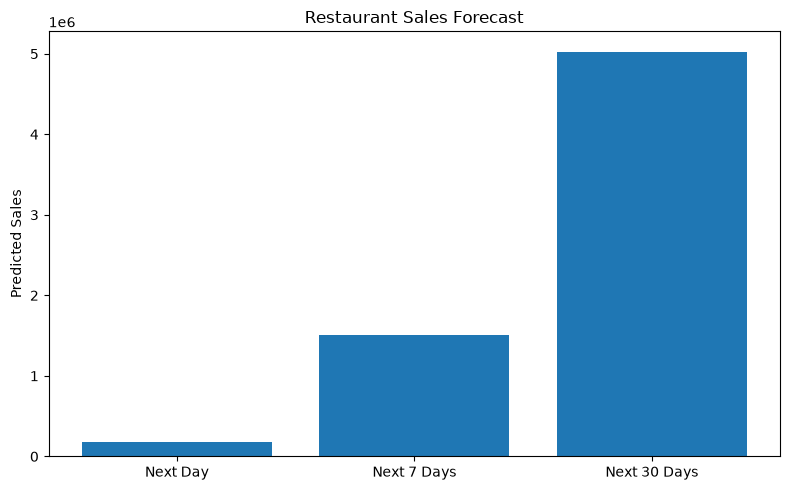

In [386]:
# Plot final forecasts

plt.figure(figsize=(8, 5))

plt.bar(
    ["Next Day", "Next 7 Days","Next 30 Days"],
    [forecast_1d, forecast_7d,forecast_30d]
)

plt.title("Restaurant Sales Forecast")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

## Project Conclusion

This notebook follows a leakage-safe time-series forecasting workflow:

1. Clean transaction-level restaurant sales data.
2. Aggregate transactions into daily sales.
3. Engineer calendar, cyclical, lag, rolling, change, and ratio features.
4. Correct rolling/change features so they use only past observations.
5. Review feature redundancy with correlation.
6. Perform **manual + automatic feature selection using training data only, producing exactly 12 final features**.
7. Preserve important seasonal structure such as `dow_sin` and `dow_cos` rather than dropping features solely because of correlation.
8. Train Linear Regression and Random Forest models.
9. Tune Random Forest models with `TimeSeriesSplit`.
10. Select the final model for each horizon using chronological test MAE.
11. Produce next-day, next-7-day, and next-30-day forecasts.

The feature-selection stage is intentionally not forced to a fixed number of features. The final set is selected from model importance plus domain knowledge so useful forecasting signals are not discarded unnecessarily.

For percentage error, SMAPE and WAPE are also reported because ordinary MAPE can become unstable when actual sales values are very small.
